In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# show all columns when printing a dataframe
pd.set_option('display.max_columns', None)

In [2]:
# read the kick dataset
df = pd.read_csv('kick_1.csv', low_memory=False)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41476 entries, 0 to 41475
Data columns (total 31 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   PurchaseID                         41476 non-null  int64  
 1   PurchaseTimestamp                  41476 non-null  int64  
 2   PurchaseDate                       41476 non-null  object 
 3   Auction                            41432 non-null  object 
 4   VehYear                            41432 non-null  float64
 5   Make                               41432 non-null  object 
 6   Color                              41432 non-null  object 
 7   Transmission                       41432 non-null  object 
 8   WheelTypeID                        41432 non-null  object 
 9   WheelType                          41380 non-null  object 
 10  VehOdo                             41432 non-null  float64
 11  Nationality                        41432 non-null  obj

In [3]:
# brief look at all the data.
df.describe(include='all')

,PurchaseID,PurchaseTimestamp,PurchaseDate,Auction,VehYear,Make,Color,Transmission,WheelTypeID,WheelType,VehOdo,Nationality,Size,TopThreeAmericanName,MMRAcquisitionAuctionAveragePrice,MMRAcquisitionAuctionCleanPrice,MMRAcquisitionRetailAveragePrice,MMRAcquisitonRetailCleanPrice,MMRCurrentAuctionAveragePrice,MMRCurrentAuctionCleanPrice,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,MMRCurrentRetailRatio,PRIMEUNIT,AUCGUART,VNST,VehBCost,IsOnlineSale,WarrantyCost,ForSale,IsBadBuy
count,41476.000000,4.147600e+04,41476,41432,41432.000000,41432,41432,41432,41432,41380,41432.000000,41432,41432,41432,41416,41429,41429,41327,41429,41429,41409,41409,41116,41432,41432,41432,41432,41432,41432.000000,41476,41476.000000
unique,NaN,NaN,497,3,NaN,30,17,4,5,4,NaN,6,13,5,9271,10010,11070,11583,9183,9890,10935,11363,25870,3,3,31,1869,6,NaN,6,NaN
top,NaN,NaN,24/11/2009 10:00,MANHEIM,NaN,CHEVROLET,SILVER,AUTO,1,Alloy,NaN,AMERICAN,MEDIUM,GM,0,0,0,0,0,0,0,0,#VALUE!,?,?,TX,7500,0,NaN,Yes,NaN
freq,NaN,NaN,242,22168,NaN,9548,8541,39930,20426,20406,NaN,34616,17540,14075,502,415,502,501,287,206,287,287,178,39634,39634,9076,459,39940,NaN,27402,NaN
mean,20737.500000,1.262260e+09,NaN,NaN,2005.360615,NaN,NaN,NaN,NaN,NaN,71300.010427,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1273.050758,NaN,0.129497
std,11973.234219,1.796895e+07,NaN,NaN,1.730587,NaN,NaN,NaN,NaN,NaN,14724.041171,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,599.188662,NaN,0.335753
min,0.000000,1.231114e+09,NaN,NaN,2001.000000,NaN,NaN,NaN,NaN,NaN,577.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,462.000000,NaN,0.000000
25%,10368.750000,1.247530e+09,NaN,NaN,2004.000000,NaN,NaN,NaN,NaN,NaN,61578.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,834.000000,NaN,0.000000
50%,20737.500000,1.262045e+09,NaN,NaN,2005.000000,NaN,NaN,NaN,NaN,NaN,73128.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1155.000000,NaN,0.000000
75%,31106.250000,1.277770e+09,NaN,NaN,2007.000000,NaN,NaN,NaN,NaN,NaN,82259.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1623.000000,NaN,0.000000


In [4]:
print(df.shape)

(41476, 31)


In [5]:
# check the unique values in the categorical columns
cat_check = ['Auction', 'Transmission', 'WheelType', 'Size', 'Nationality','TopThreeAmericanName', 'Color', 'PRIMEUNIT', 'AUCGUART','ForSale', 'IsOnlineSale', 'VehYear']

for c in cat_check:
    print(c, df[c].unique())

Auction ['OTHER' 'MANHEIM' nan 'ADESA']
Transmission ['AUTO' 'MANUAL' 'Manual' nan '?']
WheelType ['Covers' 'Alloy' '?' 'Special' nan]
Size ['MEDIUM' 'COMPACT' 'LARGE' 'MEDIUM SUV' 'SPECIALTY' 'CROSSOVER' 'VAN'
 'LARGE SUV' 'SMALL TRUCK' 'LARGE TRUCK' 'SMALL SUV' 'SPORTS' '?' nan]
Nationality ['AMERICAN' 'OTHER ASIAN' 'USA' 'TOP LINE ASIAN' 'OTHER' '?' nan]
TopThreeAmericanName ['CHRYSLER' 'GM' 'OTHER' 'FORD' '?' nan]
Color ['RED' 'SILVER' 'WHITE' 'BLUE' 'BEIGE' 'BLACK' 'GREEN' 'GREY' 'NOT AVAIL'
 'GOLD' 'PURPLE' 'ORANGE' 'MAROON' 'YELLOW' 'OTHER' 'BROWN' nan '?']
PRIMEUNIT ['?' 'NO' 'YES' nan]
AUCGUART ['?' 'GREEN' 'RED' nan]
ForSale ['Yes' 'No' '?' 'yes' '0' 'YES']
IsOnlineSale ['0' '-1' '2' '4' '1' nan '?']
VehYear [2008. 2007. 2004. 2006. 2005. 2003. 2009. 2001. 2002.   nan 2010.]


In [6]:
# find rows where the 'Auction' column has no values, a lot more rows seem to also have no values.
isAuctionEmpty = df[df['Auction'].isna()]
isAuctionEmpty.head(100)

,PurchaseID,PurchaseTimestamp,PurchaseDate,Auction,VehYear,Make,Color,Transmission,WheelTypeID,WheelType,VehOdo,Nationality,Size,TopThreeAmericanName,MMRAcquisitionAuctionAveragePrice,MMRAcquisitionAuctionCleanPrice,MMRAcquisitionRetailAveragePrice,MMRAcquisitonRetailCleanPrice,MMRCurrentAuctionAveragePrice,MMRCurrentAuctionCleanPrice,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,MMRCurrentRetailRatio,PRIMEUNIT,AUCGUART,VNST,VehBCost,IsOnlineSale,WarrantyCost,ForSale,IsBadBuy
20512,20512,1279065600,14/07/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20513,20513,1279065600,14/07/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20514,20514,1279065600,14/07/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20515,20515,1279065600,14/07/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20516,20516,1279065600,14/07/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20676,20676,1286496000,8/10/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20677,20677,1286496000,8/10/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20678,20678,1286928000,13/10/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20679,20679,1286928000,13/10/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20680,20680,1286928000,13/10/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0


In [7]:
# find rows where the 'TopThreeAmericanName' column has no values, a lot more rows seem to also have no values. By eye, same rows as Auction.
isTopThreeAmericanNameEmpty = df[df['TopThreeAmericanName'].isna()]
isTopThreeAmericanNameEmpty.head(100)

,PurchaseID,PurchaseTimestamp,PurchaseDate,Auction,VehYear,Make,Color,Transmission,WheelTypeID,WheelType,VehOdo,Nationality,Size,TopThreeAmericanName,MMRAcquisitionAuctionAveragePrice,MMRAcquisitionAuctionCleanPrice,MMRAcquisitionRetailAveragePrice,MMRAcquisitonRetailCleanPrice,MMRCurrentAuctionAveragePrice,MMRCurrentAuctionCleanPrice,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,MMRCurrentRetailRatio,PRIMEUNIT,AUCGUART,VNST,VehBCost,IsOnlineSale,WarrantyCost,ForSale,IsBadBuy
20512,20512,1279065600,14/07/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20513,20513,1279065600,14/07/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20514,20514,1279065600,14/07/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20515,20515,1279065600,14/07/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20516,20516,1279065600,14/07/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20676,20676,1286496000,8/10/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20677,20677,1286496000,8/10/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20678,20678,1286928000,13/10/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20679,20679,1286928000,13/10/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0
20680,20680,1286928000,13/10/2010 10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0


In [8]:
# see if these two variables have the same number of NaN values.
print(df['Auction'].isna().sum(), 'rows have no Auction value')
print(df['TopThreeAmericanName'].isna().sum(), 'rows have no TopThreeAmericanName value')

44 rows have no Auction value
44 rows have no TopThreeAmericanName value


In [9]:
# determine how many rows have x amount of columns with no values in them.
df.isna().sum().value_counts().head(10)

44     16
0       5
47      4
67      2
96      1
60      1
149     1
360     1
Name: count, dtype: int64

In [10]:
# drop the 44 rows, as Auction (and TopThreeAmericanName) seems to have values consistently, and same ones have NaN.
print(df['Auction'].isna().sum(), 'rows have no Auction value')
print()
print(df['Auction'].value_counts())

44 rows have no Auction value

Auction
MANHEIM    22168
ADESA      11086
OTHER       8178
Name: count, dtype: int64


In [11]:
# count how many PRIMEUNIT and AUCGUART values are missing values or '?'. As the number is large, will drop.
primeunitquestionmark = (df['PRIMEUNIT'] == '?').sum()
primeunitna = df['PRIMEUNIT'].isna().sum()
aucguartquestionmark = (df['AUCGUART'] == '?').sum()
aucguartna = df['AUCGUART'].isna().sum()

print(primeunitquestionmark + primeunitna, 'rows have no PRIMEUNIT value')
print(aucguartquestionmark + aucguartna, 'rows have no AUCGUART value')

39678 rows have no PRIMEUNIT value
39678 rows have no AUCGUART value


In [12]:
# how many bad buys are in the dataset. Approximate value to aim for in the training data.
print(df['IsBadBuy'].value_counts())
print()
print('Total IsBadBuy:', df['IsBadBuy'].value_counts().sum())
print()
print(df['IsBadBuy'].value_counts(normalize=True))

IsBadBuy
0    36105
1     5371
Name: count, dtype: int64

Total IsBadBuy: 41476

IsBadBuy
0    0.870503
1    0.129497
Name: proportion, dtype: float64


In [13]:
# reload data to start making changes
df = pd.read_csv('kick_1.csv', low_memory=False)

In [14]:
# change the missing values into NaN values
df = df.replace('?', np.nan)
df = df.replace('NOT AVAIL', np.nan)

In [15]:
# drop the mostly empty rows, then renumber the rows from 0 again
df = df.dropna(subset=['Auction'])
df = df.reset_index(drop=True)

In [16]:
# drop columns that are mostly missing or not useful for prediction
df = df.drop(columns=['PRIMEUNIT', 'AUCGUART', 'PurchaseID', 'PurchaseDate', 'PurchaseTimestamp','WheelType', 
                      'WheelTypeID', 'MMRCurrentRetailRatio', 'ForSale', 'TopThreeAmericanName', 'Nationality'])

In [17]:
# convert the price columns from text to numbers, turn the errors into NaN values, as some of the values are not numbers.
number_cols = ['MMRAcquisitionAuctionAveragePrice', 'MMRAcquisitionAuctionCleanPrice','MMRAcquisitionRetailAveragePrice', 'MMRAcquisitonRetailCleanPrice',
              'MMRCurrentAuctionAveragePrice', 'MMRCurrentAuctionCleanPrice','MMRCurrentRetailAveragePrice', 
              'MMRCurrentRetailCleanPrice','VehBCost', 'WarrantyCost', 'VehOdo']

for c in number_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

In [18]:
df.describe(include='all')

,Auction,VehYear,Make,Color,Transmission,VehOdo,Size,MMRAcquisitionAuctionAveragePrice,MMRAcquisitionAuctionCleanPrice,MMRAcquisitionRetailAveragePrice,MMRAcquisitonRetailCleanPrice,MMRCurrentAuctionAveragePrice,MMRCurrentAuctionCleanPrice,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,VNST,VehBCost,IsOnlineSale,WarrantyCost,IsBadBuy
count,41432,41432.000000,41432,41361,41426,41432.000000,41429,41409.000000,41422.000000,41422.000000,41320.000000,41245.000000,41245.000000,41225.000000,41225.000000,41432,41403.000000,41430,41432.000000,41432.000000
unique,3,NaN,30,15,3,NaN,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31,NaN,5,NaN,NaN
top,MANHEIM,NaN,CHEVROLET,SILVER,AUTO,NaN,MEDIUM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TX,NaN,0,NaN,NaN
freq,22168,NaN,9548,8541,39930,NaN,17540,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9076,NaN,39940,NaN,NaN
mean,NaN,2005.360615,NaN,NaN,NaN,71300.010427,NaN,6135.010433,7375.121723,8444.518130,9797.919264,6146.975464,7401.179658,8764.614797,10129.457320,NaN,6733.107867,NaN,1273.050758,0.129489
std,NaN,1.730587,NaN,NaN,NaN,14724.041171,NaN,2481.223003,2743.390412,3169.430702,3401.450935,2445.988284,2695.210161,3105.209195,3320.763133,NaN,1771.737200,NaN,599.188662,0.335745
min,NaN,2001.000000,NaN,NaN,NaN,577.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,225.000000,NaN,462.000000,0.000000
25%,NaN,2004.000000,NaN,NaN,NaN,61578.000000,NaN,4273.000000,5400.000000,6216.000000,7478.000000,4295.000000,5436.000000,6517.000000,7766.000000,NaN,5440.000000,NaN,834.000000,0.000000
50%,NaN,2005.000000,NaN,NaN,NaN,73128.500000,NaN,6105.000000,7303.000000,8383.000000,9722.000000,6074.000000,7324.000000,8704.000000,10090.000000,NaN,6710.000000,NaN,1155.000000,0.000000
75%,NaN,2007.000000,NaN,NaN,NaN,82259.250000,NaN,7783.000000,9014.000000,10597.750000,12031.500000,7756.000000,9022.000000,10922.000000,12307.000000,NaN,7900.000000,NaN,1623.000000,0.000000


In [19]:
# check how many missing values are in the number columns.
for c in number_cols:
    print(c, ':', df[c].isna().sum(), 'missing values')

MMRAcquisitionAuctionAveragePrice : 23 missing values
MMRAcquisitionAuctionCleanPrice : 10 missing values
MMRAcquisitionRetailAveragePrice : 10 missing values
MMRAcquisitonRetailCleanPrice : 112 missing values
MMRCurrentAuctionAveragePrice : 187 missing values
MMRCurrentAuctionCleanPrice : 187 missing values
MMRCurrentRetailAveragePrice : 207 missing values
MMRCurrentRetailCleanPrice : 207 missing values
VehBCost : 29 missing values
WarrantyCost : 0 missing values
VehOdo : 0 missing values


In [20]:
# fix the mixed upper/lower case, and USA means the same as AMERICAN
df['Transmission'] = df['Transmission'].replace('Manual', 'MANUAL')

print(df['Transmission'].unique())

['AUTO' 'MANUAL' nan]


In [21]:
# change Transmission into a 0/1 binary variable, to allign.
transmission_map = {'AUTO': 1, 'MANUAL': 0}
df['Transmission'] = df['Transmission'].map(transmission_map)

print(df['Transmission'].value_counts(dropna=False))

Transmission
1.0    39930
0.0     1496
NaN        6
Name: count, dtype: int64


In [22]:
# IsOnlineSale should only be 0 or 1, turn other values into NaN. 
df['IsOnlineSale'] = pd.to_numeric(df['IsOnlineSale'], errors='coerce')
df['IsOnlineSale'] = df['IsOnlineSale'].replace([-1, 2, 4], np.nan)

print(df['IsOnlineSale'].value_counts(dropna=False))

IsOnlineSale
0.0    39940
1.0      887
NaN      605
Name: count, dtype: int64


In [23]:
# a price of 0 or less is bad data - turn into NaN
for c in number_cols:
    mask = df[c] <= 0
    df.loc[mask, c] = np.nan

In [24]:
# for the 0/1 columns, fill missing values with the most common value
df['Transmission'] = df['Transmission'].fillna(1)   # nearly every car is AUTO, 6 values won't skew things too much. 6 are changed.
df['IsOnlineSale'] = df['IsOnlineSale'].fillna(0)   # nearly every sale is not online in this dataset, so 0 is the most common value. 605 are changed.

In [25]:
numerical_columns = df.select_dtypes(include=['number'])
correlation_matrix = numerical_columns.corr()
correlation_matrix

,VehYear,Transmission,VehOdo,MMRAcquisitionAuctionAveragePrice,MMRAcquisitionAuctionCleanPrice,MMRAcquisitionRetailAveragePrice,MMRAcquisitonRetailCleanPrice,MMRCurrentAuctionAveragePrice,MMRCurrentAuctionCleanPrice,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,VehBCost,IsOnlineSale,WarrantyCost,IsBadBuy
VehYear,1.000000,0.055956,-0.299009,0.603878,0.552644,0.606806,0.565072,0.600539,0.554880,0.615733,0.576302,0.347429,0.066595,-0.272248,-0.165610
Transmission,0.055956,1.000000,0.036304,0.105089,0.103363,0.076347,0.078724,0.107426,0.105742,0.083176,0.084597,0.146737,-0.008914,0.111769,0.005285
VehOdo,-0.299009,0.036304,1.000000,-0.028551,0.019263,0.016709,0.053691,-0.039895,0.005845,-0.002950,0.033139,-0.066748,0.029727,0.412781,0.079427
MMRAcquisitionAuctionAveragePrice,0.603878,0.105089,-0.028551,1.000000,0.989743,0.902620,0.902129,0.955317,0.949138,0.887405,0.886719,0.823724,0.053484,-0.056041,-0.115609
MMRAcquisitionAuctionCleanPrice,0.552644,0.103363,0.019263,0.989743,1.000000,0.893421,0.909969,0.941760,0.951047,0.876534,0.887822,0.814268,0.053064,-0.025114,-0.107302
MMRAcquisitionRetailAveragePrice,0.606806,0.076347,0.016709,0.902620,0.893421,1.000000,0.989428,0.865706,0.862386,0.932300,0.925107,0.782144,0.092106,-0.061932,-0.093656
MMRAcquisitonRetailCleanPrice,0.565072,0.078724,0.053691,0.902129,0.909969,0.989428,1.000000,0.862857,0.871543,0.924314,0.928690,0.787063,0.089565,-0.033388,-0.089190
MMRCurrentAuctionAveragePrice,0.600539,0.107426,-0.039895,0.955317,0.941760,0.865706,0.862857,1.000000,0.989979,0.910318,0.907946,0.797009,0.051351,-0.058773,-0.113527
MMRCurrentAuctionCleanPrice,0.554880,0.105742,0.005845,0.949138,0.951047,0.862386,0.871543,0.989979,1.000000,0.902183,0.916250,0.790406,0.051382,-0.029445,-0.107213
MMRCurrentRetailAveragePrice,0.615733,0.083176,-0.002950,0.887405,0.876534,0.932300,0.924314,0.910318,0.902183,1.000000,0.989289,0.775940,0.088440,-0.063860,-0.113156


In [26]:
correlation_mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

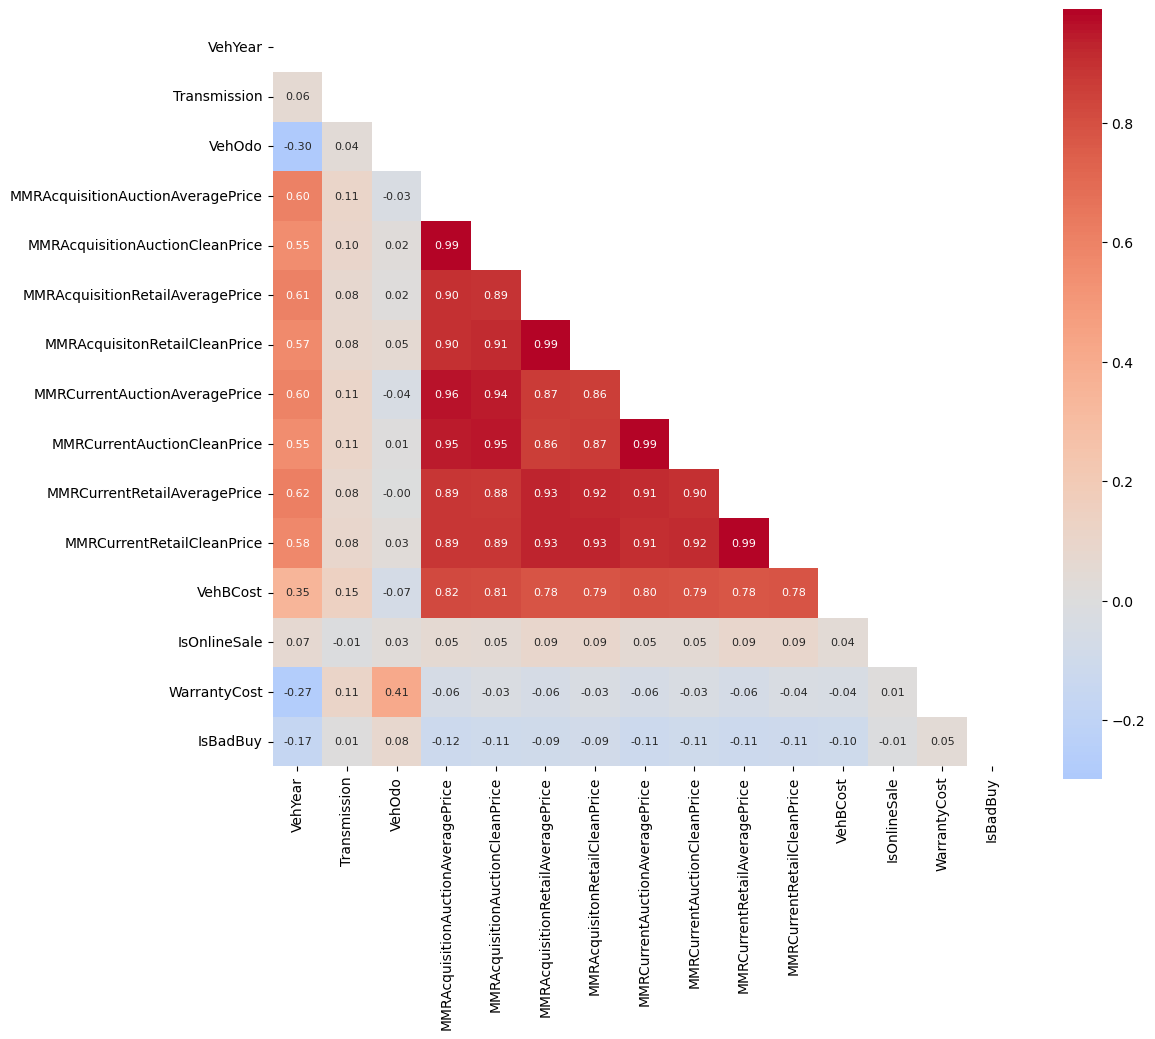

In [27]:
plt.figure(figsize=(12, 10))

sns.heatmap(correlation_matrix, annot=True, fmt=".2f",
    annot_kws={'size': 8}, cmap='coolwarm',
    center=0, mask=correlation_mask, square=True)
plt.show()

In [28]:
# drop the price columns that are highly correlated with each other, keeping a few to compare against. 
# I chose Current Retail Average Price and Current Auction Average Price, as they are the most recent prices, and the other columns are highly correlated with them.
# Ensure the preprocessed dataframe exists from earlier cells.
if 'df' not in globals():
    raise NameError("Run the earlier preprocessing cells before this one. 'df' is not defined.")

# Drop the highly correlated price columns, keeping the most recent price fields.
df = df.drop(columns=[
    'MMRAcquisitionAuctionAveragePrice',
    'MMRAcquisitionAuctionCleanPrice',
    'MMRAcquisitionRetailAveragePrice',
    'MMRAcquisitonRetailCleanPrice',
    'MMRCurrentAuctionCleanPrice',
    'MMRCurrentRetailCleanPrice'
])

In [29]:
# fill missing values in the text columns with 'UNKNOWN'
text_cols = ['Make', 'Color', 'Size', 'VNST']

for c in text_cols:
    df[c] = df[c].fillna('UNKNOWN')

print(df.isna().sum())

Auction                            0
VehYear                            0
Make                               0
Color                              0
Transmission                       0
VehOdo                             0
Size                               0
MMRCurrentAuctionAveragePrice    474
MMRCurrentRetailAveragePrice     494
VNST                               0
VehBCost                          29
IsOnlineSale                       0
WarrantyCost                       0
IsBadBuy                           0
dtype: int64


In [30]:
# turn all the categorical columns into 0/1 columns, so they can be used in the model.
print('before encoding:', df.shape)
df = pd.get_dummies(df, dtype=int)
print('after encoding: ', df.shape)

before encoding: (41432, 14)
after encoding:  (41432, 102)


In [31]:
# separate the target (what we predict) from the features (what we predict with)
y = df['IsBadBuy'].values

X = df.drop(columns=['IsBadBuy'])
feature_names = X.columns

print('X shape:', X.shape, ' y shape:', y.shape)

X shape: (41432, 101)  y shape: (41432,)


In [32]:
from sklearn.model_selection import train_test_split

random_state = 10

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=random_state)

print('Size of training set:', len(X_train))
print('Size of testing set:', len(X_test))

Size of training set: 29002
Size of testing set: 12430


In [33]:
# compare the mean and median of each column with missing values, using the training set only, to decide which one to fill with
fill_cols = ['MMRCurrentAuctionAveragePrice', 'MMRCurrentRetailAveragePrice', 'VehBCost']

for c in fill_cols:
    print(c)
    print('mean:', round(X_train[c].mean(), 1))
    print('median:', round(X_train[c].median(), 1))

MMRCurrentAuctionAveragePrice
mean: 6186.1
median: 6098.0
MMRCurrentRetailAveragePrice
mean: 8822.8
median: 8735.5
VehBCost
mean: 6732.7
median: 6715.0


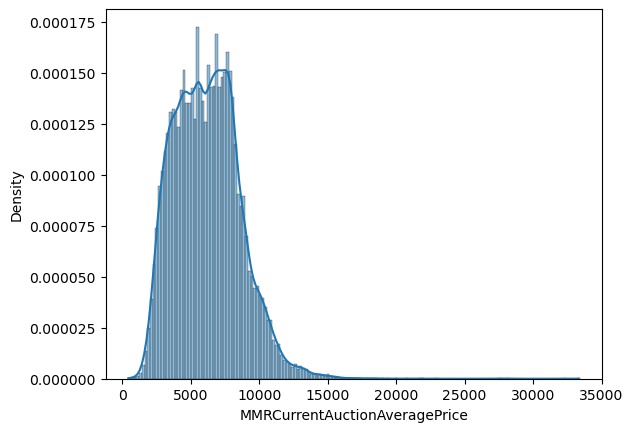

In [34]:
# plot of the distribution of MMRCurrentAuctionAveragePrice, to see if the mean or median is a better value to fill in the missing values with. 
# median appears to be a better value to fill in the missing values with, as the distribution is skewed to the right, and the mean is higher than the median.
dg = sns.histplot(df['MMRCurrentAuctionAveragePrice'].dropna(), kde=True, stat="density")
plt.show()

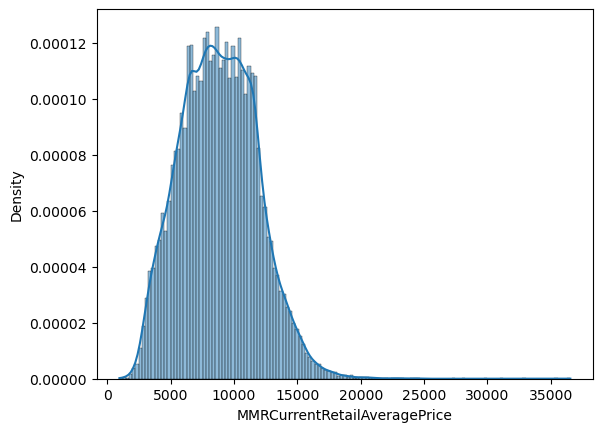

In [35]:
# plot of the distribution of MMRCurrentRetailAveragePrice, to see if the mean or median is a better value to fill in the missing values with. 
# median appears to be a better value to fill in the missing values with, as the distribution is skewed to the right, and the mean is higher than the median. Same as above.
dg = sns.histplot(df['MMRCurrentRetailAveragePrice'].dropna(), kde=True, stat="density")
plt.show()

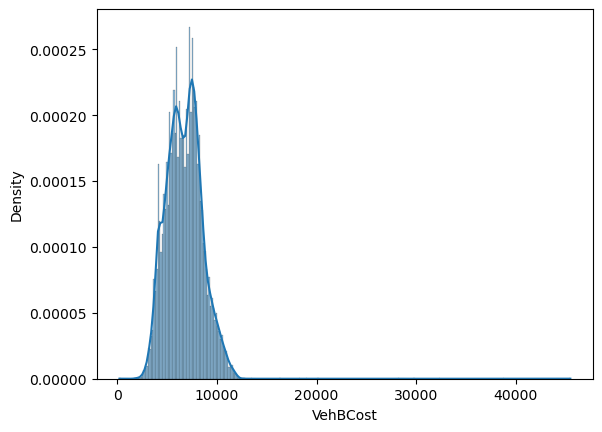

In [36]:
# plot of the distribution of VehBCost, to see if the mean or median is a better value to fill in the missing values with. 
# median appears to be a better value to fill in the missing values with, as the distribution is skewed to the right, and the mean is higher than the median. Same as both above.
dg = sns.histplot(df['VehBCost'].dropna(), kde=True, stat="density")
plt.show()

In [37]:
# fill missing values with the median, calculated from the training set.
auction_fill = X_train['MMRCurrentAuctionAveragePrice'].median()
retail_fill = X_train['MMRCurrentRetailAveragePrice'].median()
cost_fill   = X_train['VehBCost'].median()

X_train['MMRCurrentAuctionAveragePrice'] = X_train['MMRCurrentAuctionAveragePrice'].fillna(auction_fill)
X_test['MMRCurrentAuctionAveragePrice']  = X_test['MMRCurrentAuctionAveragePrice'].fillna(auction_fill)

X_train['MMRCurrentRetailAveragePrice'] = X_train['MMRCurrentRetailAveragePrice'].fillna(retail_fill)
X_test['MMRCurrentRetailAveragePrice']  = X_test['MMRCurrentRetailAveragePrice'].fillna(retail_fill)

X_train['VehBCost'] = X_train['VehBCost'].fillna(cost_fill)
X_test['VehBCost']  = X_test['VehBCost'].fillna(cost_fill)

In [38]:
# check there are no missing values left in either data sets.
print('missing in training set:', X_train.isna().sum().sum())
print('missing in testing set: ', X_test.isna().sum().sum())

missing in training set: 0
missing in testing set:  0


In [39]:
# sklearn expects numpy arrays, not DataFrames
X_train = X_train.values
X_test = X_test.values

In [40]:
# check both sets have a similar share of bad buys
print('train bad buy rate:', y_train.mean().round(4))
print('test bad buy rate: ', y_test.mean().round(4))

train bad buy rate: 0.1295
test bad buy rate:  0.1295


In [41]:
df.describe(include='all')

,VehYear,Transmission,VehOdo,MMRCurrentAuctionAveragePrice,MMRCurrentRetailAveragePrice,VehBCost,IsOnlineSale,WarrantyCost,IsBadBuy,Auction_ADESA,Auction_MANHEIM,Auction_OTHER,Make_ACURA,Make_BUICK,Make_CADILLAC,Make_CHEVROLET,Make_CHRYSLER,Make_DODGE,Make_FORD,Make_GMC,Make_HONDA,Make_HYUNDAI,Make_INFINITI,Make_ISUZU,Make_JEEP,Make_KIA,Make_LEXUS,Make_LINCOLN,Make_MAZDA,Make_MERCURY,Make_MINI,Make_MITSUBISHI,Make_NISSAN,Make_OLDSMOBILE,Make_PONTIAC,Make_SATURN,Make_SCION,Make_SUBARU,Make_SUZUKI,Make_TOYOTA,Make_VOLKSWAGEN,Make_VOLVO,Color_BEIGE,Color_BLACK,Color_BLUE,Color_BROWN,Color_GOLD,Color_GREEN,Color_GREY,Color_MAROON,Color_ORANGE,Color_OTHER,Color_PURPLE,Color_RED,Color_SILVER,Color_UNKNOWN,Color_WHITE,Color_YELLOW,Size_COMPACT,Size_CROSSOVER,Size_LARGE,Size_LARGE SUV,Size_LARGE TRUCK,Size_MEDIUM,Size_MEDIUM SUV,Size_SMALL SUV,Size_SMALL TRUCK,Size_SPECIALTY,Size_SPORTS,Size_UNKNOWN,Size_VAN,VNST_AL,VNST_AZ,VNST_CA,VNST_CO,VNST_FL,VNST_GA,VNST_ID,VNST_IL,VNST_IN,VNST_KY,VNST_LA,VNST_MO,VNST_MS,VNST_NC,VNST_NE,VNST_NH,VNST_NJ,VNST_NM,VNST_NV,VNST_NY,VNST_OH,VNST_OK,VNST_OR,VNST_PA,VNST_SC,VNST_TN,VNST_TX,VNST_UT,VNST_VA,VNST_WA,VNST_WV
count,41432.000000,41432.000000,41432.000000,40958.000000,40938.000000,41403.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.00000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.00000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000,41432.000000
mean,2005.360615,0.963893,71300.010427,6190.048415,8826.060018,6733.107867,0.021409,1273.050758,0.129489,0.267571,0.535045,0.197384,0.000459,0.009968,0.000410,0.230450,0.126931,0.178244,0.155870,0.008472,0.006348,0.023098,0.000652,0.001979,0.023774,0.032270,0.000314,0.001303,0.012840,0.012720,0.000459,0.013733,0.028625,0.003524,0.05684,0.030049,0.001858,0.000410,0.020322,0.016026,0.001762,0.000290,0.021578,0.106005,0.141316,0.006010,0.073832,0.043348,0.102529,0.025077,0.006155,0.003282,0.004948,0.088362,0.206145,0.001714,0.166297,0.003403,0.097388,0.023508,0.119907,0.020033,0.045786,0.423344,0.110277,0.032149,0.011923,0.024088,0.010258,0.000072,0.081266,0.004320,0.081652,0.078876,0.087444,0.126714,0.031063,0.000338,0.003982,0.01173,0.005551,0.008423,0.018295,0.009944,0.086745,0.000628,0.002341,0.007651,0.005768,0.013347,0.000145,0.000603,0.062633,0.003282,0.016895,0.040114,0.035504,0.219058,0.003982,0.026381,0.003282,0.003307
std,1.730587,0.186560,14724.041171,2399.615073,3027.803136,1771.737200,0.144744,599.188662,0.335745,0.442698,0.498776,0.398029,0.021410,0.099343,0.020252,0.421126,0.332900,0.382723,0.362736,0.091652,0.079420,0.150217,0.025520,0.044444,0.152346,0.176718,0.017711,0.036079,0.112587,0.112063,0.021410,0.116383,0.166753,0.059258,0.23154,0.170725,0.043070,0.020252,0.141103,0.125578,0.041939,0.017016,0.145301,0.307848,0.348351,0.077291,0.261500,0.203642,0.303347,0.156362,0.078211,0.057200,0.070168,0.283824,0.404541,0.041361,0.372351,0.058238,0.296490,0.151513,0.324857,0

# Task 2 - Decision Tree Modelling
## 2.1 Decision Tree using default settings

### 2.1A. Decision Tree parameters and overfitting

The `DecisionTreeClassifier` with default settings was used to build the Decision Tree. For reproducibility, `random_state=10` was used.

The following main parameters were used:

* `criterion = 'gini'`
* `splitter = 'best'`
* `max_depth = None`
* `min_samples_split = 2`
* `min_samples_leaf = 1`
* `max_features = None`
* `class_weight = None`
* `random_state = 10`

The `max_depth=None` setting allows the Decision Tree to grow with a lot of nodes until the stopping criteria are reached. Combining this with `min_samples_split=2` and `min_samples_leaf=1`, generates a tree that is highly complex and follows the training data closely. These parameters leads to an overfitted model that will be supported by the succeeding observations.

In [42]:
from sklearn.tree import DecisionTreeClassifier

# default decision tree training
def_dt_model = DecisionTreeClassifier(random_state=random_state)
def_dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,10
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [43]:
print('*****Model parameters******\n', def_dt_model.get_params(deep=True))
print('Number of leaves in the trained model:', def_dt_model.get_n_leaves())

*****Model parameters******
 {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 10, 'splitter': 'best'}
Number of leaves in the trained model: 4196


In [44]:
def_dt_model_important_params = {
    'criterion': def_dt_model.get_params()['criterion'],
    'splitter': def_dt_model.get_params()['splitter'],
    'max_depth': def_dt_model.get_params()['max_depth'],
    'min_samples_split': def_dt_model.get_params()['min_samples_split'],
    'min_samples_leaf': def_dt_model.get_params()['min_samples_leaf'],
    'max_features': def_dt_model.get_params()['max_features'],
    'class_weight': def_dt_model.get_params()['class_weight'],
    'random_state': def_dt_model.get_params()['random_state']
}

def_dt_model_important_params

{'criterion': 'gini',
 'splitter': 'best',
 'max_depth': None,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': None,
 'class_weight': None,
 'random_state': 10}

### 2.1B Data Split
During the preprocessing stage, the dataset was divided into training and testing with a split 70% training and 30% testing. In addition, stratified sampling (`stratify=y`) was used to preserve the proportion of training and testing data. For reproduciibility among team members, a `random_state` of 10 was used.

In [45]:
print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))
print("Training proportion:", len(X_train) / (len(X_train) + len(X_test)))
print("Testing proportion:", len(X_test) / (len(X_train) + len(X_test)))

Training observations: 29002
Testing observations: 12430
Training proportion: 0.6999903456265688
Testing proportion: 0.3000096543734312


### 2.1C. Classification accuracy

The default Decision Tree has a **training accuracy of 1.0000 (100.00%)** and a **test accuracy of 0.7870 (78.70%)**. There is a difference of **0.2130 (21.30%)**.

| Dataset  |    Accuracy |
| -------- | ----------: |
| Training | **100.00%** |
| Test     |  **78.70%** |

Because the target variable `IsBadBuy` is imbalanced as shown in classification report under `support` column, accuracy alone can not be used as the only factor to assess the model performance. The classification report shows that the model achieved low values for the **Bad Buy class (class 1)**:

* **Precision:** 0.19
* **Recall:** 0.20
* **F1-score:** 0.19
* **Support:** 1,610 observations

The model identifies only 20% of the actual bad buy vehicles in the test dataset (refer to classification report, recall column). Therefore, even though the test accuracy is high, **78.70**, it does not mean that the model effectively identified bad buy vehicles.

In [46]:
training_accuracy = def_dt_model.score(X_train, y_train)
print(f"Training set accuracy:, {training_accuracy:.4f}")

Training set accuracy:, 1.0000


In [47]:
testing_accuracy = def_dt_model.score(X_test, y_test)
print(f"Testing set accuracy: , {testing_accuracy:.4f}")

Testing set accuracy: , 0.7870


#### Training and Test Accuracy Gap

In [48]:
training_test_accuracy_gap = training_accuracy - testing_accuracy
print(f"Accuracy gap: {training_test_accuracy_gap:.4f}")

Accuracy gap: 0.2130


#### Classification Performance
Due to imbalance of target variable `IsBadBuy`, Accuracy alone is not enough to measure the model's performance. Evaluation metrics, Precision, Recall, and F1-score are also examined with particular attention to class 1 (Bad Buy).

In [49]:
y_test_pred = def_dt_model.predict(X_test)
print(y_test_pred)

[0 0 0 ... 0 0 0]


In [50]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.88      0.87      0.88     10820
           1       0.19      0.20      0.19      1610

    accuracy                           0.79     12430
   macro avg       0.54      0.54      0.54     12430
weighted avg       0.79      0.79      0.79     12430



### 2.1D. Size of Decision Tree
Model visualization of the default Decision Tree shows a very large complex tree. Counting the nodes by eye is impossible. Instead we used the model property `tree_.node_count` and method `get_n_leaves()`:

- **8,391 nodes**
- **4,196 leaves**

In [51]:
print("Number of nodes:", def_dt_model.tree_.node_count)
print("Number of leaves:", def_dt_model.get_n_leaves())

Number of nodes: 8391
Number of leaves: 4196


#### Visualise Default Decision Tree Model

In [52]:
# Allow us to display images directly in the notebook.
from IPython.display import Image, display
from io import StringIO
from sklearn.tree import export_graphviz
import pydot

def visualize_model(model, depth=None):
    # export_graphviz() expects a file to write to. Rather than writing to a file and
    # then reading it back in, we can use StringIO() to create a temporary file in memory.
    dotfile = StringIO()
    export_graphviz(model, out_file=dotfile, feature_names=feature_names, class_names=['Good Buy', 'Bad Buy'], max_depth=depth)
    
    # Use pydot to load this dot file, and then display it in the notebook.
    # Dot files can contain multiple graphs, we want the first one, hence [0].
    graph = pydot.graph_from_dot_data(dotfile.getvalue())
    display(Image(graph[0].create_png()))

visualize_model(def_dt_model)

### 2.1E. First and Second Split
To be able to clearly see the first split and second split the tree was displayed with a depth of 2. The `export_graphviz` function was modified to accept `max_depth` parameter. Also added `class_names` parameter for the tree graph to display the class (whether Good Buy or Bad Buy) on each node.

The first split variable is **`VehYear`** with a threshold of `<= 2005.5`.

The second split variables are:
- **`VehBCost`**, with a threshold of `<= 4017.5`
- **`MMRCurrentRetailAveragePrice`**, with a threshold of `<= 20877.0`

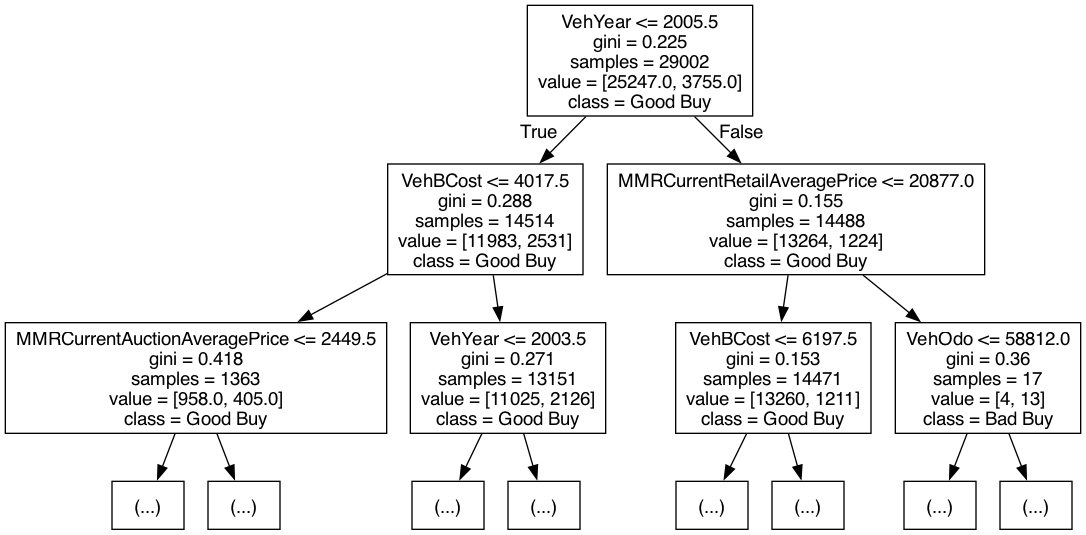

In [53]:
visualize_model(def_dt_model, depth=2)

### 2.1F. Five Most Important Variables

The table below shows the five most important variables identified. The feature variable, **`VehOdo`** contributed the most in reducing impurity across the tree and important to note that this does not mean that it causes the decision to be a Good Buy or Bad Buy. 

| Rank | Variable | Feature Importance |
|---|---|---:|
| 1 | `VehOdo` | **0.142879** |
| 2 | `VehBCost` | **0.141989** |
| 3 | `MMRCurrentRetailAveragePrice` | **0.125490** |
| 4 | `MMRCurrentAuctionAveragePrice` | **0.119440** |
| 5 | `WarrantyCost` | **0.065724** |

In [54]:
def display_feature_importances(model, feature_names, features_to_display=20):
    # Grab feature importances from the model and feature names from the original X.
    # We get the feature names from the original dataframe because
    # the feature array does not include column titles.
    importances = model.feature_importances_
    
    # Sort feature importances in descending order.
    indices = np.argsort(importances)
    indices = np.flip(indices, axis=0)
    
    # Limit the output to the requested number of features.
    indices = indices[:features_to_display]
    
    for i in indices:
        print(feature_names[i], ':', importances[i])
    
    print("Number of leaves:", model.get_n_leaves())

display_feature_importances(def_dt_model, feature_names, features_to_display=5)

VehOdo : 0.14287945261617171
VehBCost : 0.14198819226780307
MMRCurrentRetailAveragePrice : 0.1254895289507429
MMRCurrentAuctionAveragePrice : 0.11943896823687127
WarrantyCost : 0.06572437523780658
Number of leaves: 4196


### 2.1G. Evidence of Model Overfitting
Evidences of overfitting are found in default Decision Tree. The model achieved 100% accuracy on the the training dataset but only 78.70% on the test dataset, a difference of 21.30%. This shows that the model performed better on training data versus unseen test data.
The number of nodes (8391), and number leaves (4196), show that the tree is highly complex and closely follows the training data. By plotting the training data versus data using depth values 2 through 20, it shows that as depth increases the accuracy of training data increases while the accuracy of testing data decreases.

In [55]:
print(f"Training accuracy: {training_accuracy:.4f}")
print(f"Test accuracy:     {testing_accuracy:.4f}")
print(f"Accuracy gap:      {training_accuracy - testing_accuracy:.4f}")

Training accuracy: 1.0000
Test accuracy:     0.7870
Accuracy gap:      0.2130


In [56]:
print(f"Number of nodes:  {def_dt_model.tree_.node_count}")
print(f"Number of leaves: {def_dt_model.get_n_leaves()}")

Number of nodes:  8391
Number of leaves: 4196


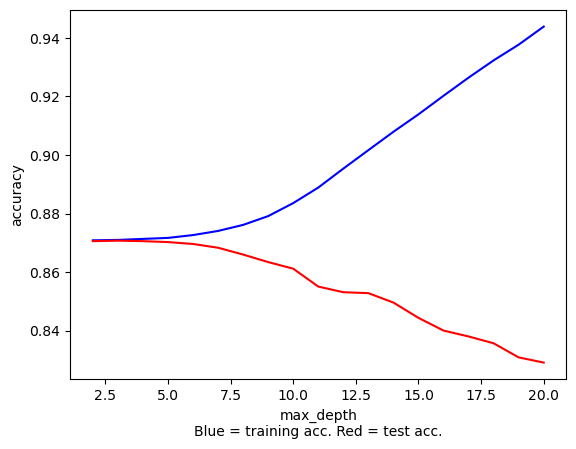

In [57]:
import matplotlib.pyplot as plt

# Check the model performance for max depth from 2-20, store into two lists that we can plot.
test_score = []
train_score = []
for max_depth in range(2, 21):
    temp_model = DecisionTreeClassifier(max_depth=max_depth, random_state=random_state)
    temp_model.fit(X_train, y_train)
    test_score.append(temp_model.score(X_test, y_test))
    train_score.append(temp_model.score(X_train, y_train))

# Plot max depth hyperparameter values vs training and test accuracy score.
plt.plot(range(2, 21), train_score, 'b', range(2, 21), test_score, 'r')
plt.xlabel('max_depth\nBlue = training acc. Red = test acc.')
plt.ylabel('accuracy')
plt.show()

## 2.2 Decision Tree using GridSearchCV

### 2.2A. Optimal Parameters

GridSearchCV was used to find the optimal hyperparameters to reduce the complexity of the Decision Tree and to provide better generalisation of the unseen data.

The initial hyperparameters used were:
- `criterion`: `gini` and `entropy`
- `max_depth`: values from **2 to 6**
- `min_samples_leaf`: **20, 30, 40 and 50**

Using the above and 10-fold cross-validation, it identified the following hyperparameter:
- `criterion = entropy`
- `max_depth = 3`
- `min_samples_leaf = 20`

Based on the identified values above, refined the hyperparameters by using:
- `criterion`: `gini` and `entropy`
- `max_depth`: values from **2 to 5**
- `min_samples_leaf`: values from **1 to 19**

**Rerunning the model with the above and 10-fold cross-validation, the identified final hyperparameter were:**
- `criterion`: `entropy`
- `max_depth`: **4**
- `min_samples_leaf`: **10**

In [58]:
from sklearn.model_selection import GridSearchCV

# Define grid search CV parameters.
params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': range(2, 7),
    'min_samples_leaf': range(20, 60, 10)
}

def perform_grid_search(X_train, y_train, X_test, y_test, params, num_folds=10):
    # Instantiate the search class. Pass it the model to use (the DecisionTreeClassifier), and the number of folds.
    cv = GridSearchCV(param_grid=params, estimator=DecisionTreeClassifier(random_state=random_state), cv=num_folds, verbose=1, n_jobs=-1)
    cv.fit(X_train, y_train)

    # Display the accuracy of the best fit model.
    print("Train accuracy:", cv.score(X_train, y_train))
    print("Test accuracy:", cv.score(X_test, y_test))
    
    # Evaluate the best fit model.
    y_pred = cv.predict(X_test)
    print(classification_report(y_test, y_pred))
    
    # Display parameters of the best model.
    print(cv.best_params_)
    return cv

perform_grid_search(X_train, y_train, X_test, y_test, params)

Fitting 10 folds for each of 40 candidates, totalling 400 fits
Train accuracy: 0.8707330528929039
Test accuracy: 0.8704746580852776
              precision    recall  f1-score   support

           0       0.87      1.00      0.93     10820
           1       0.50      0.00      0.00      1610

    accuracy                           0.87     12430
   macro avg       0.69      0.50      0.47     12430
weighted avg       0.82      0.87      0.81     12430

{'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 20}


,estimator,DecisionTreeC...ndom_state=10)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': range(2, 7), 'min_samples_leaf': range(20, 60, 10)}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,10
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


### 2.2B. Classification Accuracy

The classification accuracy of the final tuned GridSeachCV Decision Tree for Training and Test dataset is:
| Dataset | Accuracy |
|---|---:|
| Training | **87.08** |
| Test | **87.06%** |

The training and test accuracy values are closed to each other meaning that the model generalises better on the unseen test data compare to the default Decision Tree which has a huge gap of **21.30%**.

As noted previously that the the `IsBadBuy` target variable is imbalanced, accuracy alone does not provide complete assessment of the model's performance and the classification report should also be included in the assessment.

In [59]:
params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': range(2, 6),
    'min_samples_leaf': range(1, 20)
}

cv = perform_grid_search(X_train, y_train, X_test, y_test, params)

Fitting 10 folds for each of 152 candidates, totalling 1520 fits
Train accuracy: 0.8708364940348942
Test accuracy: 0.870555108608206
              precision    recall  f1-score   support

           0       0.87      1.00      0.93     10820
           1       0.55      0.00      0.01      1610

    accuracy                           0.87     12430
   macro avg       0.71      0.50      0.47     12430
weighted avg       0.83      0.87      0.81     12430

{'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 10}


In [60]:
optimal_dt_model_cv = cv.best_estimator_
optimal_dt_model_training_accuracy = optimal_dt_model_cv.score(X_train, y_train)
optimal_dt_model_testing_accuracy = optimal_dt_model_cv.score(X_test, y_test)

print(f"Training accuracy: {optimal_dt_model_training_accuracy:.4f}")
print(f"Test accuracy:     {optimal_dt_model_testing_accuracy:.4f}")

Training accuracy: 0.8708
Test accuracy:     0.8706


### 2.2C. Size of the Chosen Decision Tree

The final tuned hyperparameters of GridSearchCV resulted in a smaller Decision Tree with:
- **29 nodes**
- **15 leaves**

The reduced Decision Tree resulted in better generalisation as shown in the accuracy result in **2.2B**.

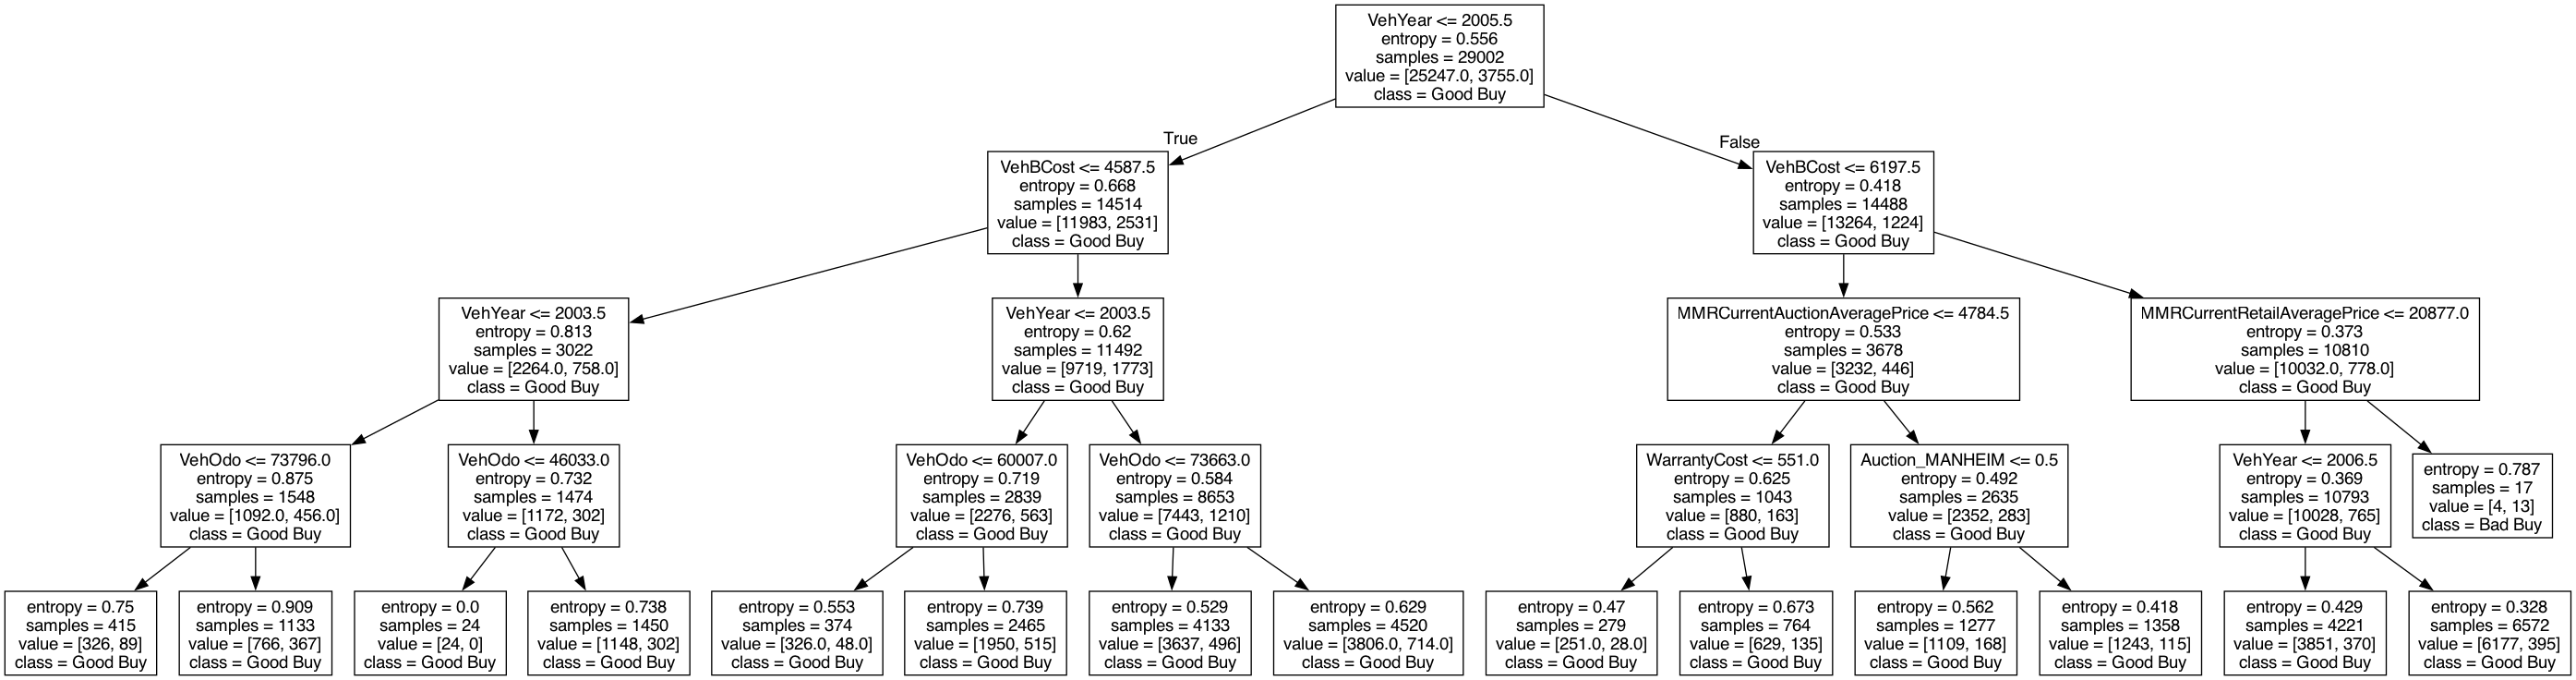

In [61]:
visualize_model(optimal_dt_model_cv)

In [62]:
print("Number of nodes:", optimal_dt_model_cv.tree_.node_count)
print("Number of leaves:", optimal_dt_model_cv.get_n_leaves())

Number of nodes: 29
Number of leaves: 15


### 2.2D. First and Second Splits

The first split variable is **`VehYear`** with a threshold of `<= 2005.5`.

The second split variables are:
- **`VehBCost`** (left), with a threshold of `<= 4587.5`
- Right **`VehBCost`** (right), with a threshold of `<= 6197.5`

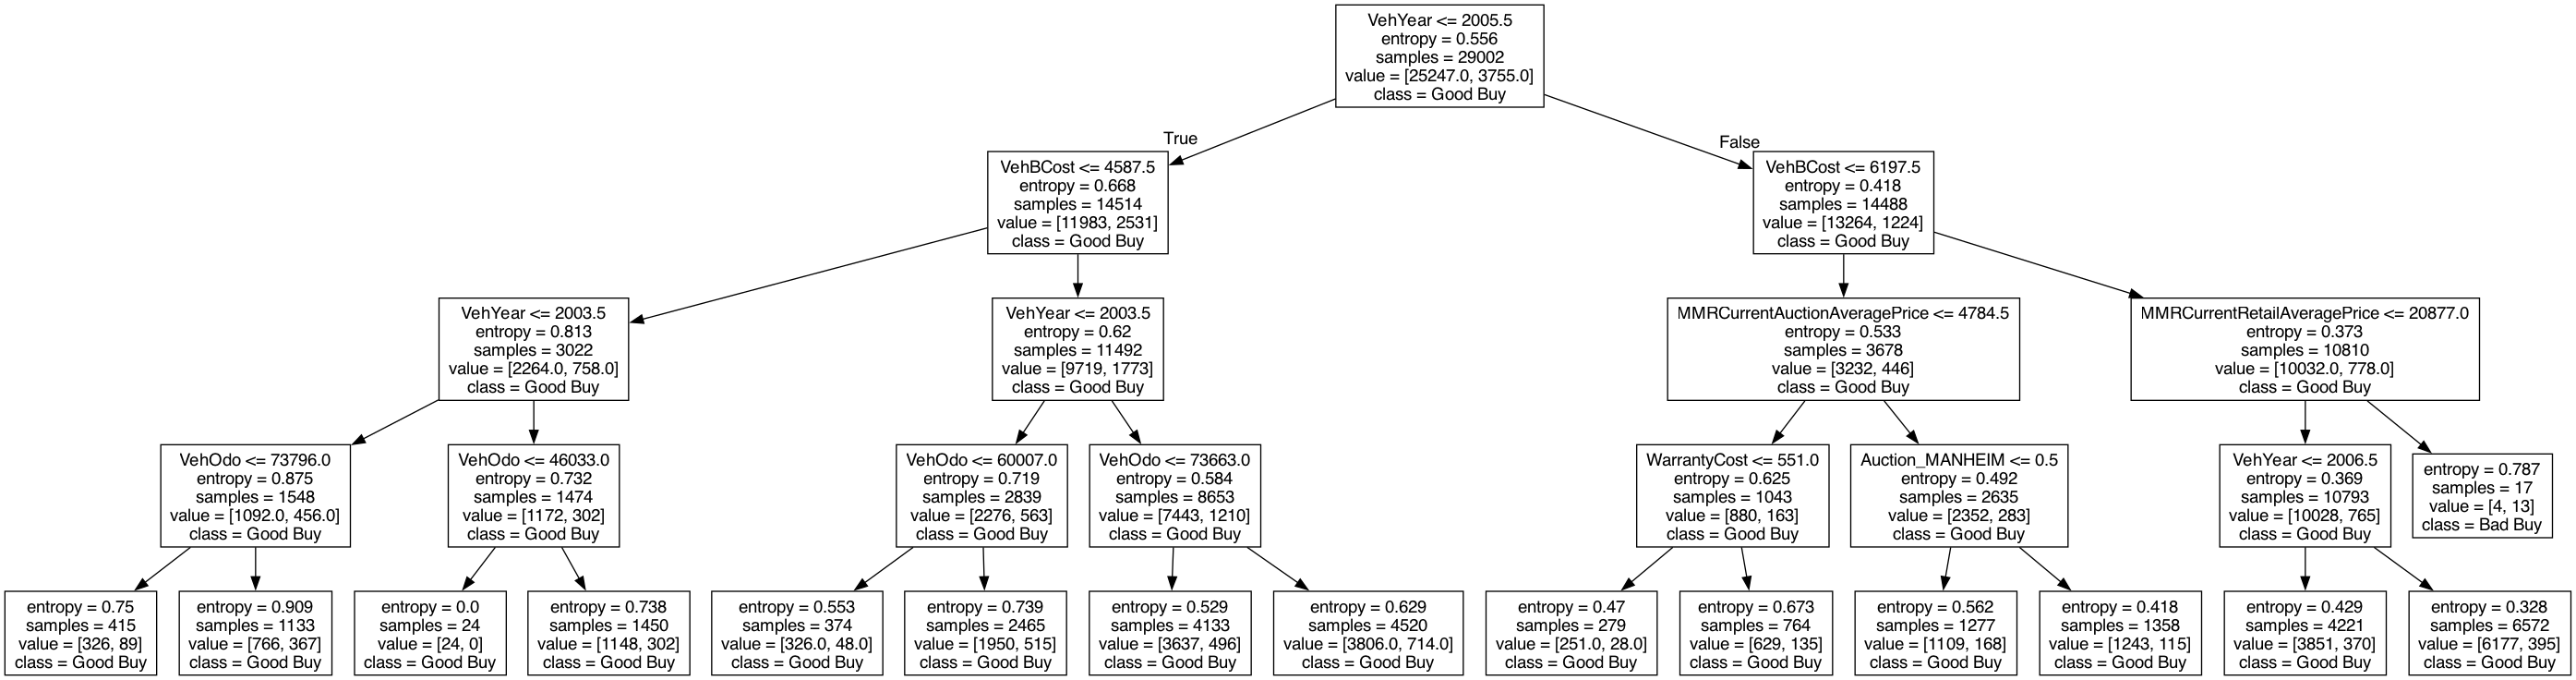

In [63]:
visualize_model(optimal_dt_model_cv)

### 2.2E. Five Most Important Variables

The five most important variables in the refined GridSearchCV Decision Tree are:

| Rank | Variable | Feature Importance |
|---|---|---:|
| 1 | `VehYear` | **0.625382** |
| 2 | `VehBCost` | **0.217982** |
| 3 | `VehOdo` | **0.067785** |
| 4 | `MMRCurrentRetailAveragePrice` | **0.049143** |
| 5 | `MMRCurrentAuctionAveragePrice` | **0.015569** |

In [64]:
display_feature_importances(optimal_dt_model_cv, feature_names, features_to_display=5)

VehYear : 0.6253824213375593
VehBCost : 0.21798198857862852
VehOdo : 0.0677847951518316
MMRCurrentRetailAveragePrice : 0.04914344615312893
MMRCurrentAuctionAveragePrice : 0.015569425093565303
Number of leaves: 15


### 2.2F. Evidence of Model Overfitting

Overfitting is less evident in the refined GridSearchCV model with a **training accuracy of 87.08%** and a **test accuracy of 87.06%**, a difference of approximately **0.03%** compared to the default decision tree with a gap of **21.30%**

This shows that the model generalises much better to unseen data. However, accuracy alone is not enough to conclude that it is effective at identifying Bad Buy vehicles and that the classification report of the model should also be considered in the assessment.

### 2.3 Comparison of the Two Decision Tree Models

The table below shows the difference of Default Decision Tree and the refined GridSearchCV in terms of accuracy, tree structure/complexity, and ROC-AUC.

| Measure | Default Decision Tree | GridSearchCV Decision Tree |
|---|---:|---:|
| Training accuracy | **100.00%** | **87.08%** |
| Test accuracy | **78.70%** | **87.06%** |
| Train-test accuracy gap | **21.30%** | **0.03%** |
| Number of nodes | **8,391** | **29** |
| Number of leaves | **4,196** | **15** |
| Criterion | `gini` | `entropy` |
| Maximum depth | `None` | **4** |
| Minimum samples per leaf | **1** | **10** |
| Test ROC-AUC | **0.5364** | **0.6532** |

The accuracy gap between training and test of Default Decision Tree is **21.30%** which indicates overfitting as it performed well on training versus test dataset. On the other hand, the accuracy gap in GridSearchCV is so small, approximately **0.03%**, which shows that it generalises better on unseen test data.

The tree structure of the Default Decision Tree is highly complex with **8,391 nodes** and **4,196 leaves**. The GridSearchCV tree structure is much simpler with **29 nodes** and **15** leaves.

The ROC-AUC test result of GridSearchCV model is higher, **0.6532**, compare to the result of Default Decision Tree, **0.5364**. This shows that, varying the threshold, the first discriminates better based on predicted probabilties.

Overall, the **GridSeachCV Decision Tree is the better model** based on accuracy, less evidence of overfitting, simpler tree structure, and higher ROC-AUC result.

However, highlighting that accuracy alone is not enough to measure the model's performance in predicting Bad Buy vehicles because the target variable `IsBadBuy` is imbalanced.

In [65]:
# probability prediction from decision tree
y_pred_optimal_dt_model_cv = optimal_dt_model_cv.predict(X_test)
y_pred_proba_optimal_dt_model_cv = optimal_dt_model_cv.predict_proba(X_test)

print("Probability produced by decision tree for each class vs actual prediction on IsBadBuy (0 = Good Buy, 1 = Bad Buy).")
print("You should be able to see the default threshold of 0.5.")
print("(probs on zero)  (probs on one)  (prediction made)  (label)")

# print top 10
for i in range(20):
    print(f"{y_pred_proba_optimal_dt_model_cv[i][0]:.13f}  {y_pred_proba_optimal_dt_model_cv[i][1]:.13f} {y_test_pred[i]:<10d} {y_test[i]:10d}")

Probability produced by decision tree for each class vs actual prediction on IsBadBuy (0 = Good Buy, 1 = Bad Buy).
You should be able to see the default threshold of 0.5.
(probs on zero)  (probs on one)  (prediction made)  (label)
0.8420353982301  0.1579646017699 0                   1
0.9398965307365  0.0601034692635 0                   0
0.8799903218001  0.1200096781999 0                   0
0.7910750507099  0.2089249492901 0                   0
0.9153166421208  0.0846833578792 0                   0
0.8684416601410  0.1315583398590 0                   0
0.9398965307365  0.0601034692635 0                   0
0.8799903218001  0.1200096781999 0                   0
0.9398965307365  0.0601034692635 0                   0
0.9123430466714  0.0876569533286 0                   0
0.7910750507099  0.2089249492901 0                   0
0.9398965307365  0.0601034692635 0                   0
0.9123430466714  0.0876569533286 0                   0
0.9398965307365  0.0601034692635 0                   0

In [66]:
from sklearn.metrics import roc_auc_score

y_pred_proba_def_dt_model = def_dt_model.predict_proba(X_test)
y_pred_proba_optimal_dt_model_cv = optimal_dt_model_cv.predict_proba(X_test)

roc_index_def_dt_model = roc_auc_score(y_test, y_pred_proba_def_dt_model[:, 1])
roc_index_optimal_dt_model_cv = roc_auc_score(y_test, y_pred_proba_optimal_dt_model_cv[:, 1])

print("ROC index on test for default model:", roc_index_def_dt_model)
print("ROC index on test for grid search model:", roc_index_optimal_dt_model_cv)

ROC index on test for default model: 0.5364065854582611
ROC index on test for grid search model: 0.6532462026842402


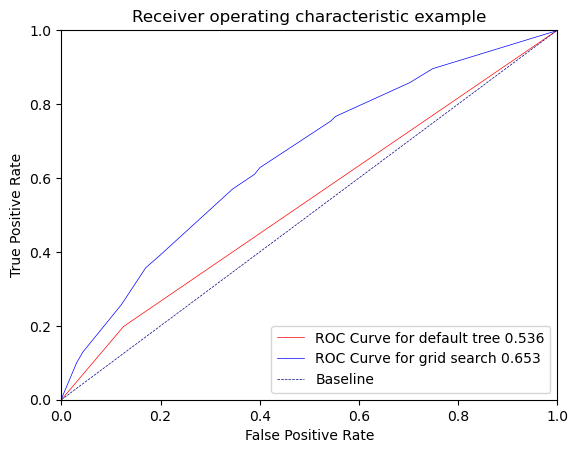

In [67]:
from sklearn.metrics import roc_curve

fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_pred_proba_def_dt_model[:,1])
fpr_dt_cv, tpr_dt_cv, thresholds_dt_cv = roc_curve(y_test, y_pred_proba_optimal_dt_model_cv[:,1])

plt.plot(fpr_dt, tpr_dt, label='ROC Curve for default tree {:.3f}'.format(roc_index_def_dt_model), color='red', lw=0.5)
plt.plot(fpr_dt_cv, tpr_dt_cv, label='ROC Curve for grid search {:.3f}'.format(roc_index_optimal_dt_model_cv), color='blue', lw=0.5)
plt.plot([0, 1], [0, 1], color='navy', lw=0.5, label='Baseline', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example')
plt.legend(loc="lower right")
plt.show()

### 2.4 Characteristics of cars most likely to be a bad buy

Based on the GridSearchCV Decision Tree, the decision path that leads to a **Bad Buy** terminal node is:

* `VehYear > 2005.5`
* `VehBCost > 6197.5`
* `MMRCurrentRetailAveragePrice > 20877.0`

This terminal node contains **17 vehicles** and majority of this class is Bad Buy, **4 Good Buy** and **13 Bad Buy** observations (`value = [4, 13]`).

Therefore, the characteristics of cars most likely to be predicted to be a Bad Buy have a **vehicle year greater than approximately 2005, a vehicle cost above `$6,197.50`, and a current retail average price above `$20,877`**.

Individually, these characteristics are easy to comprehend based on their intuitive meanings. `VehYear` describes the vehicle's year, `VehBCost` represents the vehicle cost, and `MMRCurrentRetailAveragePrice` represents the estimated current retail market price. It is also easy to follow the path based on the given numerical thresholds of these features.

However, the combination of these characteristics may be harder to comprehend for someone who is not familiar with this business domain to comprehend why a newer vehicle with a relatively high vehicle cost and high estimated retail value was predicted to be a Bad Buy. This combination is identified by the model as a predictive pattern from the dataset and does not clearly explains why these combination is a Bad Buy.

It is important to note that decision tree provides **predictive associations rather than causal explanations** for why a car may be classified as a Bad Buy.


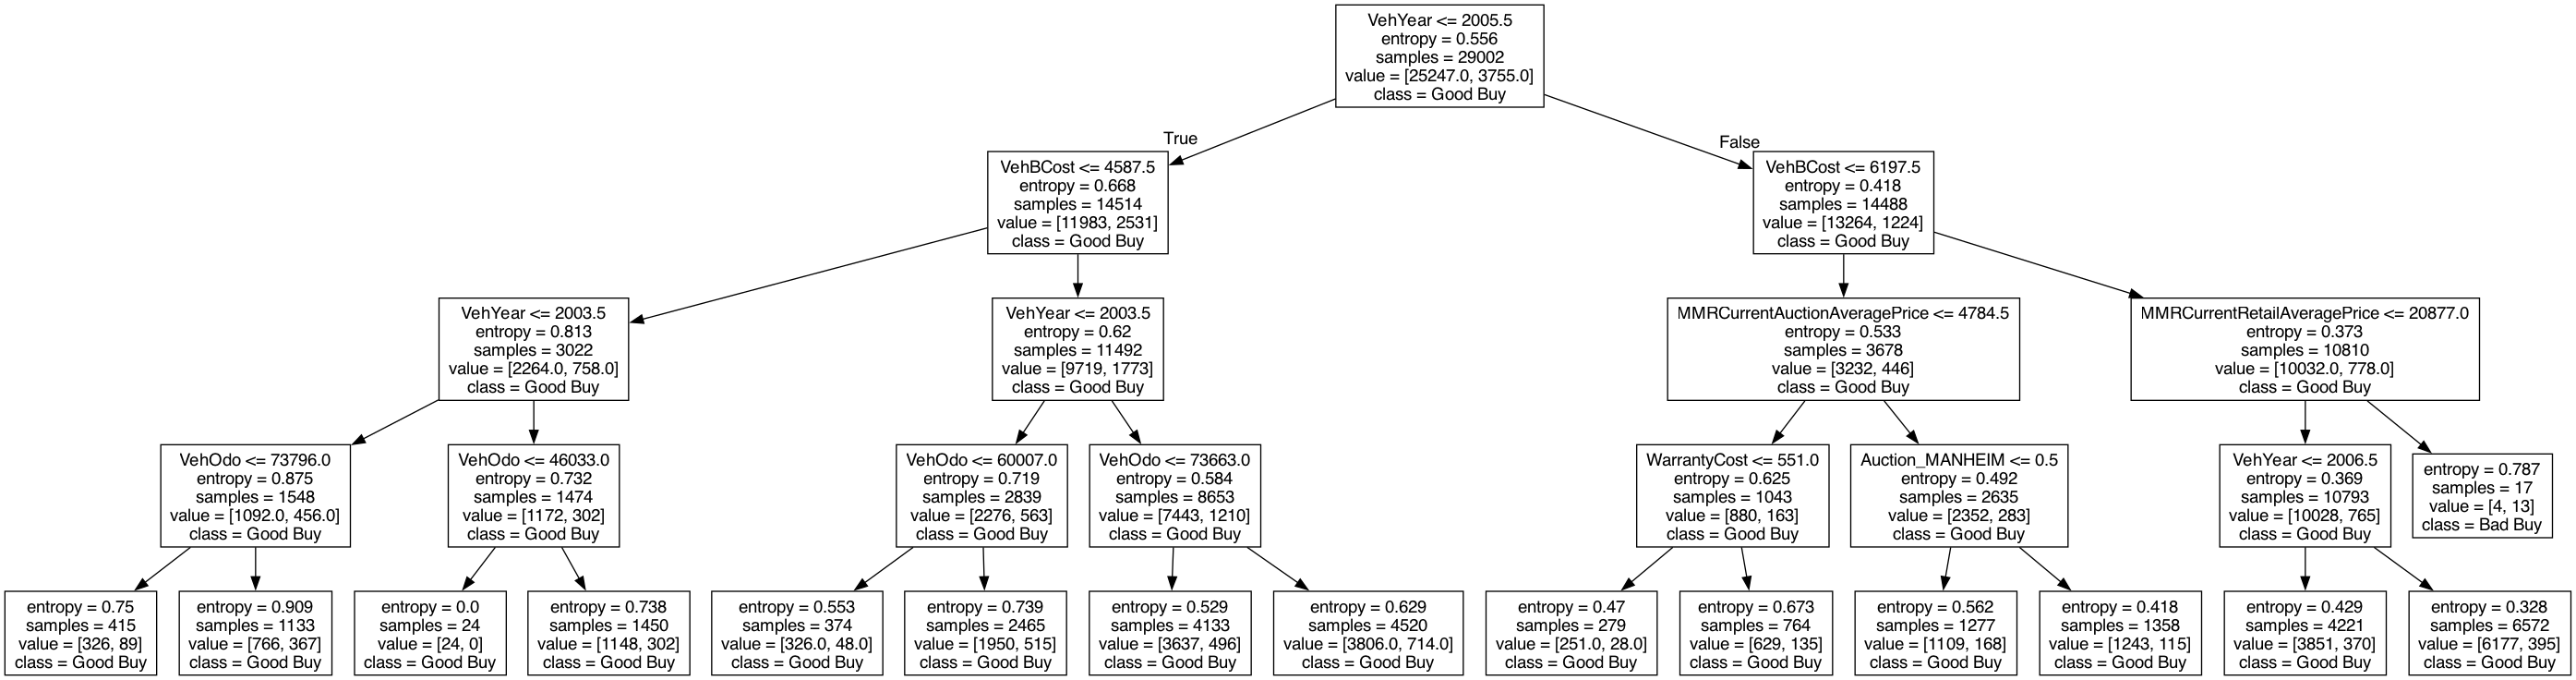

In [68]:
visualize_model(optimal_dt_model_cv)

## Saving the Model

In [69]:
import pickle
 
with open('decision_tree_model.pickle', 'wb') as f:
    pickle.dump([optimal_dt_model_cv, roc_index_optimal_dt_model_cv, fpr_dt_cv, tpr_dt_cv], f)

# Task 3 - Regression Modelling

Using **binary logistic regression** to predict `IsBadBuy`. with
101 encoded predictors, stratified 70/30 train/test split, and `random_state=10` as
the Task 2 decision tree.

The additional regression-specific processing is standardisation. `StandardScaler`
is fitted to the existing training inputs and then applied to both partitions. 

In [70]:
from IPython.display import Markdown, display
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

# Task 3 deliberately consumes the split produced by Task 1.
task3_required = ["X_train", "X_test", "y_train", "y_test", "feature_names"]
task3_missing = [name for name in task3_required if name not in globals()]
if task3_missing:
    raise RuntimeError(
        "Run Tasks 1 and 2 before Task 3. Missing shared variables: "
        + ", ".join(task3_missing)
    )

X_train_task3_raw = np.asarray(X_train).copy()
X_test_task3_raw = np.asarray(X_test).copy()
y_train_task3 = np.asarray(y_train).copy()
y_test_task3 = np.asarray(y_test).copy()
task3_feature_names = np.asarray(feature_names).copy()

assert X_train_task3_raw.shape == (29002, 101)
assert X_test_task3_raw.shape == (12430, 101)
assert len(task3_feature_names) == X_train_task3_raw.shape[1]

task3_scaler = StandardScaler()
X_train_task3 = task3_scaler.fit_transform(X_train_task3_raw)
X_test_task3 = task3_scaler.transform(X_test_task3_raw)

print("Task 1/Task 3 pipeline hand-off confirmed")
print("Training set:", X_train_task3.shape)
print("Test set:    ", X_test_task3.shape)
print("Predictors:  ", len(task3_feature_names))
print("Training kick rate:", y_train_task3.mean().round(4))
print("Test kick rate:    ", y_test_task3.mean().round(4))

Task 1/Task 3 pipeline hand-off confirmed
Training set: (29002, 101)
Test set:     (12430, 101)
Predictors:   101
Training kick rate: 0.1295
Test kick rate:     0.1295


## 3.1 Full-variable logistic regression

`GridSearchCV` tunes `C`, the inverse of regularisation strength, over the
course range from $10^{-6}$ to $10^3$. Ten-fold cross-validation and ROC AUC are
used because only about 13% of observations are kicks.

In [71]:
task3_c_values = [10.0 ** exponent for exponent in range(-6, 4)]
task3_parameter_grid = {"C": task3_c_values}

task3_full_search = GridSearchCV(
    LogisticRegression(random_state=random_state, max_iter=3000),
    param_grid=task3_parameter_grid,
    cv=10,
    scoring="roc_auc",
    n_jobs=-1,
    return_train_score=True,
)
task3_full_search.fit(X_train_task3, y_train_task3)

print("C values searched:", task3_c_values)
print("Best parameters:", task3_full_search.best_params_)
print(f"Best mean cross-validation ROC AUC: {task3_full_search.best_score_:.4f}")

C values searched: [1e-06, 1e-05, 0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
Best parameters: {'C': 0.01}
Best mean cross-validation ROC AUC: 0.6595


In [72]:
def task3_evaluate_model(name, estimator, train_inputs, test_inputs):
    train_prediction = estimator.predict(train_inputs)
    test_prediction = estimator.predict(test_inputs)
    train_probability = estimator.predict_proba(train_inputs)[:, 1]
    test_probability = estimator.predict_proba(test_inputs)[:, 1]
    metrics = {
        "model": name,
        "train_accuracy": accuracy_score(y_train_task3, train_prediction),
        "test_accuracy": accuracy_score(y_test_task3, test_prediction),
        "train_balanced_accuracy": balanced_accuracy_score(y_train_task3, train_prediction),
        "test_balanced_accuracy": balanced_accuracy_score(y_test_task3, test_prediction),
        "train_roc_auc": roc_auc_score(y_train_task3, train_probability),
        "test_roc_auc": roc_auc_score(y_test_task3, test_probability),
        "test_precision_kick": precision_score(y_test_task3, test_prediction, zero_division=0),
        "test_recall_kick": recall_score(y_test_task3, test_prediction, zero_division=0),
        "test_f1_kick": f1_score(y_test_task3, test_prediction, zero_division=0),
    }
    return metrics, train_prediction, test_prediction, train_probability, test_probability


(
    task3_full_result,
    task3_full_train_pred,
    task3_full_test_pred,
    task3_full_train_prob,
    task3_full_test_prob,
) = task3_evaluate_model(
    "Full logistic regression",
    task3_full_search.best_estimator_,
    X_train_task3,
    X_test_task3,
)

print(pd.Series(task3_full_result).drop("model").astype(float).round(4).to_string())
print("\nTest classification report:")
print(classification_report(y_test_task3, task3_full_test_pred, digits=4, zero_division=0))

train_accuracy             0.8704
test_accuracy              0.8705
train_balanced_accuracy    0.5012
test_balanced_accuracy     0.5005
train_roc_auc              0.6704
test_roc_auc               0.6738
test_precision_kick        0.5000
test_recall_kick           0.0012
test_f1_kick               0.0025

Test classification report:
              precision    recall  f1-score   support

           0     0.8706    0.9998    0.9307     10820
           1     0.5000    0.0012    0.0025      1610

    accuracy                         0.8705     12430
   macro avg     0.6853    0.5005    0.4666     12430
weighted avg     0.8226    0.8705    0.8105     12430



In [73]:
task3_full_coefficients = task3_full_search.best_estimator_.coef_[0]
task3_full_importance = pd.DataFrame({
    "variable": task3_feature_names,
    "coefficient": task3_full_coefficients,
})
task3_full_importance["absolute_coefficient"] = task3_full_importance["coefficient"].abs()
task3_full_importance["odds_ratio"] = np.exp(task3_full_importance["coefficient"])
task3_full_importance = task3_full_importance.sort_values(
    "absolute_coefficient", ascending=False
)

print("Top 5 variables by absolute standardised coefficient:")
display(task3_full_importance.head(5).round(4))
print("Largest positive coefficients (higher estimated kick probability):")
display(task3_full_importance.sort_values("coefficient", ascending=False).head(10).round(4))
print("Largest negative coefficients:")
display(task3_full_importance.sort_values("coefficient").head(10).round(4))

Top 5 variables by absolute standardised coefficient:


,variable,coefficient,absolute_coefficient,odds_ratio
0,VehYear,-0.3416,0.3416,0.7106
5,VehBCost,-0.1981,0.1981,0.8203
2,VehOdo,0.1262,0.1262,1.1345
14,Make_CHEVROLET,-0.1034,0.1034,0.9018
9,Auction_MANHEIM,-0.0969,0.0969,0.9076


Largest positive coefficients (higher estimated kick probability):


,variable,coefficient,absolute_coefficient,odds_ratio
2,VehOdo,0.1262,0.1262,1.1345
1,Transmission,0.0830,0.0830,1.0866
63,Size_MEDIUM SUV,0.0802,0.0802,1.0835
8,Auction_ADESA,0.0799,0.0799,1.0832
37,Make_SUZUKI,0.0640,0.0640,1.0661
93,VNST_PA,0.0607,0.0607,1.0626
72,VNST_CA,0.0578,0.0578,1.0595
54,Color_UNKNOWN,0.0528,0.0528,1.0543
60,Size_LARGE SUV,0.0523,0.0523,1.0537
15,Make_CHRYSLER,0.0517,0.0517,1.0531


Largest negative coefficients:


,variable,coefficient,absolute_coefficient,odds_ratio
0,VehYear,-0.3416,0.3416,0.7106
5,VehBCost,-0.1981,0.1981,0.8203
14,Make_CHEVROLET,-0.1034,0.1034,0.9018
9,Auction_MANHEIM,-0.0969,0.0969,0.9076
59,Size_LARGE,-0.0663,0.0663,0.9358
76,VNST_ID,-0.0498,0.0498,0.9515
83,VNST_NC,-0.0492,0.0492,0.9520
69,Size_VAN,-0.0474,0.0474,0.9537
75,VNST_GA,-0.0473,0.0473,0.9538
12,Make_BUICK,-0.0405,0.0405,0.9603


## 3.2 Reduced-variable logistic regression using RFECV

In [74]:
task3_rfe = RFECV(
    LogisticRegression(random_state=random_state, max_iter=3000),
    step=5,
    min_features_to_select=5,
    cv=10,
    scoring="roc_auc",
    n_jobs=-1,
)
task3_rfe.fit(X_train_task3, y_train_task3)

X_train_task3_reduced = task3_rfe.transform(X_train_task3)
X_test_task3_reduced = task3_rfe.transform(X_test_task3)
task3_selected_feature_names = task3_feature_names[task3_rfe.support_]

print(f"Original encoded predictors: {X_train_task3.shape[1]}")
print(f"RFECV-selected predictors:   {task3_rfe.n_features_}")
print("\nSelected predictors:")
for task3_variable in task3_selected_feature_names:
    print("-", task3_variable)

Original encoded predictors: 101
RFECV-selected predictors:   91

Selected predictors:
- VehYear
- Transmission
- VehOdo
- MMRCurrentAuctionAveragePrice
- MMRCurrentRetailAveragePrice
- VehBCost
- IsOnlineSale
- WarrantyCost
- Auction_ADESA
- Auction_MANHEIM
- Auction_OTHER
- Make_ACURA
- Make_BUICK
- Make_CADILLAC
- Make_CHEVROLET
- Make_CHRYSLER
- Make_DODGE
- Make_FORD
- Make_GMC
- Make_HYUNDAI
- Make_INFINITI
- Make_ISUZU
- Make_JEEP
- Make_KIA
- Make_LEXUS
- Make_LINCOLN
- Make_MAZDA
- Make_MERCURY
- Make_MINI
- Make_MITSUBISHI
- Make_NISSAN
- Make_PONTIAC
- Make_SATURN
- Make_SCION
- Make_SUZUKI
- Make_TOYOTA
- Make_VOLKSWAGEN
- Make_VOLVO
- Color_BLACK
- Color_BROWN
- Color_GOLD
- Color_GREEN
- Color_MAROON
- Color_ORANGE
- Color_OTHER
- Color_PURPLE
- Color_RED
- Color_SILVER
- Color_UNKNOWN
- Color_WHITE
- Color_YELLOW
- Size_COMPACT
- Size_LARGE
- Size_LARGE SUV
- Size_LARGE TRUCK
- Size_MEDIUM
- Size_MEDIUM SUV
- Size_SMALL SUV
- Size_SMALL TRUCK
- Size_SPECIALTY
- Size_SPOR

In [75]:
task3_reduced_search = GridSearchCV(
    LogisticRegression(random_state=random_state, max_iter=3000),
    param_grid=task3_parameter_grid,
    cv=10,
    scoring="roc_auc",
    n_jobs=-1,
    return_train_score=True,
)
task3_reduced_search.fit(X_train_task3_reduced, y_train_task3)

print("Best reduced-model parameters:", task3_reduced_search.best_params_)
print(f"Best mean cross-validation ROC AUC: {task3_reduced_search.best_score_:.4f}")

Best reduced-model parameters: {'C': 0.01}
Best mean cross-validation ROC AUC: 0.6608


In [76]:
(
    task3_reduced_result,
    task3_reduced_train_pred,
    task3_reduced_test_pred,
    task3_reduced_train_prob,
    task3_reduced_test_prob,
) = task3_evaluate_model(
    "RFECV-reduced logistic regression",
    task3_reduced_search.best_estimator_,
    X_train_task3_reduced,
    X_test_task3_reduced,
)

task3_results = pd.DataFrame([task3_full_result, task3_reduced_result]).set_index("model")
print("Full versus reduced results:")
display(task3_results.round(4).T)
print("Reduced-model test classification report:")
print(classification_report(y_test_task3, task3_reduced_test_pred, digits=4, zero_division=0))

Full versus reduced results:


model,Full logistic regression,RFECV-reduced logistic regression
train_accuracy,0.8704,0.8704
test_accuracy,0.8705,0.8705
train_balanced_accuracy,0.5012,0.5012
test_balanced_accuracy,0.5005,0.5005
train_roc_auc,0.6704,0.6704
test_roc_auc,0.6738,0.6737
test_precision_kick,0.5000,0.5000
test_recall_kick,0.0012,0.0012
test_f1_kick,0.0025,0.0025


Reduced-model test classification report:
              precision    recall  f1-score   support

           0     0.8706    0.9998    0.9307     10820
           1     0.5000    0.0012    0.0025      1610

    accuracy                         0.8705     12430
   macro avg     0.6853    0.5005    0.4666     12430
weighted avg     0.8226    0.8705    0.8105     12430



## 3.3 ROC comparison, overfitting, and interpretation

ROC curves compare ranking performance across every threshold. Train/test accuracy
and ROC AUC gaps are used to assess overfitting. Standardised logistic coefficients
describe associations rather than causation.

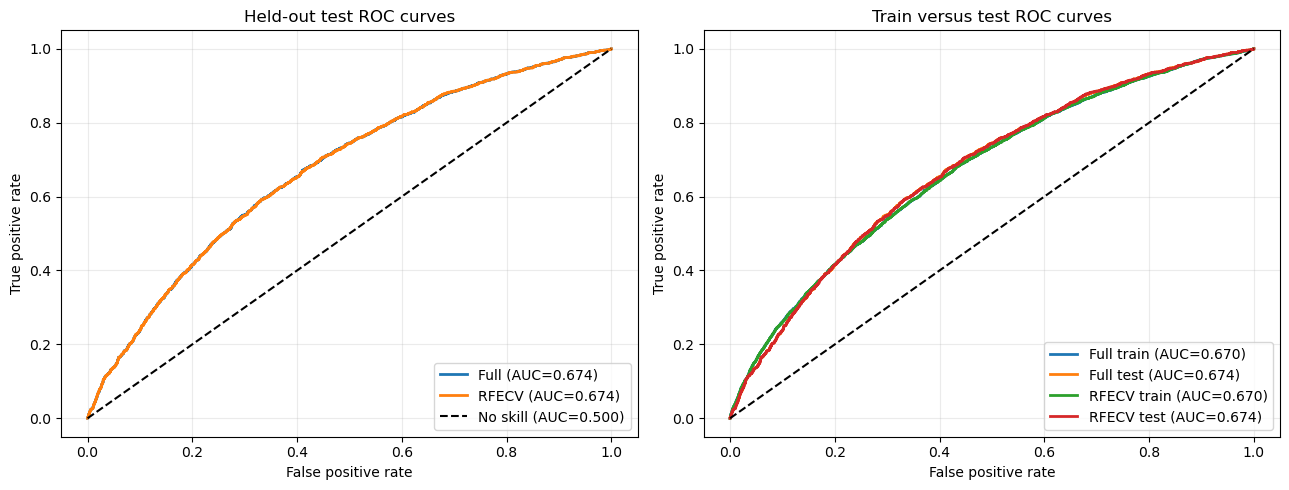

In [77]:
task3_full_train_fpr, task3_full_train_tpr, _ = roc_curve(
    y_train_task3, task3_full_train_prob
)
task3_full_test_fpr, task3_full_test_tpr, _ = roc_curve(
    y_test_task3, task3_full_test_prob
)
task3_reduced_train_fpr, task3_reduced_train_tpr, _ = roc_curve(
    y_train_task3, task3_reduced_train_prob
)
task3_reduced_test_fpr, task3_reduced_test_tpr, _ = roc_curve(
    y_test_task3, task3_reduced_test_prob
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(task3_full_test_fpr, task3_full_test_tpr, lw=2,
             label=f"Full (AUC={task3_full_result['test_roc_auc']:.3f})")
axes[0].plot(task3_reduced_test_fpr, task3_reduced_test_tpr, lw=2,
             label=f"RFECV (AUC={task3_reduced_result['test_roc_auc']:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", label="No skill (AUC=0.500)")
axes[0].set(title="Held-out test ROC curves", xlabel="False positive rate", ylabel="True positive rate")
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.25)

axes[1].plot(task3_full_train_fpr, task3_full_train_tpr, lw=2,
             label=f"Full train (AUC={task3_full_result['train_roc_auc']:.3f})")
axes[1].plot(task3_full_test_fpr, task3_full_test_tpr, lw=2,
             label=f"Full test (AUC={task3_full_result['test_roc_auc']:.3f})")
axes[1].plot(task3_reduced_train_fpr, task3_reduced_train_tpr, lw=2,
             label=f"RFECV train (AUC={task3_reduced_result['train_roc_auc']:.3f})")
axes[1].plot(task3_reduced_test_fpr, task3_reduced_test_tpr, lw=2,
             label=f"RFECV test (AUC={task3_reduced_result['test_roc_auc']:.3f})")
axes[1].plot([0, 1], [0, 1], "k--")
axes[1].set(title="Train versus test ROC curves", xlabel="False positive rate", ylabel="True positive rate")
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()

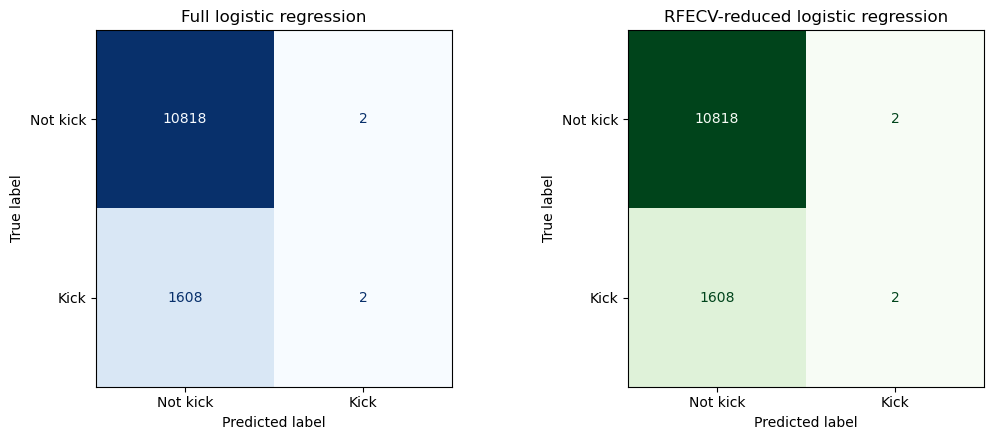

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test_task3, task3_full_test_pred),
    display_labels=["Not kick", "Kick"],
).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Full logistic regression")

ConfusionMatrixDisplay(
    confusion_matrix(y_test_task3, task3_reduced_test_pred),
    display_labels=["Not kick", "Kick"],
).plot(ax=axes[1], colorbar=False, cmap="Greens")
axes[1].set_title("RFECV-reduced logistic regression")
plt.tight_layout()
plt.show()

In [79]:
task3_comparison = task3_results[[
    "train_accuracy",
    "test_accuracy",
    "train_roc_auc",
    "test_roc_auc",
    "test_recall_kick",
]].copy()
task3_comparison["accuracy_gap"] = (
    task3_comparison["train_accuracy"] - task3_comparison["test_accuracy"]
)
task3_comparison["roc_auc_gap"] = (
    task3_comparison["train_roc_auc"] - task3_comparison["test_roc_auc"]
)

display(task3_comparison.round(4))
task3_best_model_name = task3_results["test_roc_auc"].idxmax()
task3_reduction_helpful = (
    task3_reduced_result["test_roc_auc"] >= task3_full_result["test_roc_auc"] - 0.005
    and task3_rfe.n_features_ < len(task3_feature_names)
)

print("Best held-out ROC AUC:", task3_best_model_name)
print("Was RFECV helpful?", "Yes" if task3_reduction_helpful else "No")
for task3_name, task3_row in task3_comparison.iterrows():
    task3_interpretation = (
        "little evidence of overfitting"
        if task3_row["roc_auc_gap"] < 0.03
        else "possible overfitting"
    )
    print(
        f"{task3_name}: ROC AUC gap={task3_row['roc_auc_gap']:.4f}; "
        f"{task3_interpretation}."
    )

,train_accuracy,test_accuracy,train_roc_auc,test_roc_auc,test_recall_kick,accuracy_gap,roc_auc_gap
model,,,,,,,
Full logistic regression,0.8704,0.8705,0.6704,0.6738,0.0012,-0.0001,-0.0033
RFECV-reduced logistic regression,0.8704,0.8705,0.6704,0.6737,0.0012,-0.0001,-0.0033


Best held-out ROC AUC: Full logistic regression
Was RFECV helpful? Yes
Full logistic regression: ROC AUC gap=-0.0033; little evidence of overfitting.
RFECV-reduced logistic regression: ROC AUC gap=-0.0033; little evidence of overfitting.


### Optional operating threshold

The default classification threshold is 0.5. To illustrate the sensitivity versus
false-alarm trade-off, an alternative threshold is chosen only from the training ROC
curve by maximising Youden's J statistic, then evaluated once on the test set.

In [80]:
if task3_best_model_name == "RFECV-reduced logistic regression":
    task3_operating_train_probability = task3_reduced_train_prob
    task3_operating_test_probability = task3_reduced_test_prob
else:
    task3_operating_train_probability = task3_full_train_prob
    task3_operating_test_probability = task3_full_test_prob

task3_operating_fpr, task3_operating_tpr, task3_operating_thresholds = roc_curve(
    y_train_task3, task3_operating_train_probability
)
task3_finite_thresholds = np.isfinite(task3_operating_thresholds)
task3_youden_scores = (
    task3_operating_tpr[task3_finite_thresholds]
    - task3_operating_fpr[task3_finite_thresholds]
)
task3_operating_threshold = task3_operating_thresholds[task3_finite_thresholds][
    np.argmax(task3_youden_scores)
]
task3_operating_test_prediction = (
    task3_operating_test_probability >= task3_operating_threshold
).astype(int)

task3_threshold_result = {
    "threshold": task3_operating_threshold,
    "test_accuracy": accuracy_score(y_test_task3, task3_operating_test_prediction),
    "test_balanced_accuracy": balanced_accuracy_score(y_test_task3, task3_operating_test_prediction),
    "test_precision_kick": precision_score(y_test_task3, task3_operating_test_prediction, zero_division=0),
    "test_recall_kick": recall_score(y_test_task3, task3_operating_test_prediction, zero_division=0),
    "test_f1_kick": f1_score(y_test_task3, task3_operating_test_prediction, zero_division=0),
}
print("Training-selected operating threshold and held-out test metrics:")
print(pd.Series(task3_threshold_result).round(4).to_string())

Training-selected operating threshold and held-out test metrics:
threshold                 0.1177
test_accuracy             0.5836
test_balanced_accuracy    0.6271
test_precision_kick       0.1912
test_recall_kick          0.6857
test_f1_kick              0.2990


In [81]:
task3_top_five = task3_full_importance.head(5)["variable"].tolist()
task3_top_five_text = "\n".join(
    f"{number}. `{name}`" for number, name in enumerate(task3_top_five, start=1)
)
task3_selected_text = ", ".join(f"`{name}`" for name in task3_selected_feature_names)
task3_best = task3_results.loc[task3_best_model_name]

display(Markdown(f"""## 3.4 Report-ready findings

### Full-variable model

- Function: binary logistic regression (`LogisticRegression`).
- Inputs: all {len(task3_feature_names)} encoded predictors prepared in Task 1.
- Grid: `C = 10^-6 ... 10^3`; optimal setting: `{task3_full_search.best_params_}`.
- Training accuracy: **{task3_full_result['train_accuracy']:.4f}**; test accuracy: **{task3_full_result['test_accuracy']:.4f}**.
- Training ROC AUC: **{task3_full_result['train_roc_auc']:.4f}**; test ROC AUC: **{task3_full_result['test_roc_auc']:.4f}**.
- Test kick recall at threshold 0.5: **{task3_full_result['test_recall_kick']:.4f}**.

Top five variables by absolute standardised coefficient:

{task3_top_five_text}

### RFECV-reduced model

- RFECV retained **{task3_rfe.n_features_}** of {len(task3_feature_names)} encoded predictors.
- Optimal setting: `{task3_reduced_search.best_params_}`.
- Training accuracy: **{task3_reduced_result['train_accuracy']:.4f}**; test accuracy: **{task3_reduced_result['test_accuracy']:.4f}**.
- Training ROC AUC: **{task3_reduced_result['train_roc_auc']:.4f}**; test ROC AUC: **{task3_reduced_result['test_roc_auc']:.4f}**.
- Dimensionality reduction helpful: **{'Yes' if task3_reduction_helpful else 'No'}**. Helpful means test ROC AUC remained within 0.005 of the full model while fewer predictors were used.
- Selected predictors: {task3_selected_text}.

### Interpretation and limitations

The strongest held-out ROC AUC belongs to **{task3_best_model_name}**
(test ROC AUC **{task3_best['test_roc_auc']:.4f}**). The coefficient tables describe
associations, not causation. Accuracy is not sufficient on its own because kicks are
the minority class. At the training-selected threshold of
**{task3_threshold_result['threshold']:.4f}**, test balanced accuracy was
**{task3_threshold_result['test_balanced_accuracy']:.4f}** and kick recall was
**{task3_threshold_result['test_recall_kick']:.4f}**. A deployment threshold should
ultimately reflect the relative cost of missed kicks and unnecessary inspections.
"""))

## 3.4 Report-ready findings

### Full-variable model

- Function: binary logistic regression (`LogisticRegression`).
- Inputs: all 101 encoded predictors prepared in Task 1.
- Grid: `C = 10^-6 ... 10^3`; optimal setting: `{'C': 0.01}`.
- Training accuracy: **0.8704**; test accuracy: **0.8705**.
- Training ROC AUC: **0.6704**; test ROC AUC: **0.6738**.
- Test kick recall at threshold 0.5: **0.0012**.

Top five variables by absolute standardised coefficient:

1. `VehYear`
2. `VehBCost`
3. `VehOdo`
4. `Make_CHEVROLET`
5. `Auction_MANHEIM`

### RFECV-reduced model

- RFECV retained **91** of 101 encoded predictors.
- Optimal setting: `{'C': 0.01}`.
- Training accuracy: **0.8704**; test accuracy: **0.8705**.
- Training ROC AUC: **0.6704**; test ROC AUC: **0.6737**.
- Dimensionality reduction helpful: **Yes**. Helpful means test ROC AUC remained within 0.005 of the full model while fewer predictors were used.
- Selected predictors: `VehYear`, `Transmission`, `VehOdo`, `MMRCurrentAuctionAveragePrice`, `MMRCurrentRetailAveragePrice`, `VehBCost`, `IsOnlineSale`, `WarrantyCost`, `Auction_ADESA`, `Auction_MANHEIM`, `Auction_OTHER`, `Make_ACURA`, `Make_BUICK`, `Make_CADILLAC`, `Make_CHEVROLET`, `Make_CHRYSLER`, `Make_DODGE`, `Make_FORD`, `Make_GMC`, `Make_HYUNDAI`, `Make_INFINITI`, `Make_ISUZU`, `Make_JEEP`, `Make_KIA`, `Make_LEXUS`, `Make_LINCOLN`, `Make_MAZDA`, `Make_MERCURY`, `Make_MINI`, `Make_MITSUBISHI`, `Make_NISSAN`, `Make_PONTIAC`, `Make_SATURN`, `Make_SCION`, `Make_SUZUKI`, `Make_TOYOTA`, `Make_VOLKSWAGEN`, `Make_VOLVO`, `Color_BLACK`, `Color_BROWN`, `Color_GOLD`, `Color_GREEN`, `Color_MAROON`, `Color_ORANGE`, `Color_OTHER`, `Color_PURPLE`, `Color_RED`, `Color_SILVER`, `Color_UNKNOWN`, `Color_WHITE`, `Color_YELLOW`, `Size_COMPACT`, `Size_LARGE`, `Size_LARGE SUV`, `Size_LARGE TRUCK`, `Size_MEDIUM`, `Size_MEDIUM SUV`, `Size_SMALL SUV`, `Size_SMALL TRUCK`, `Size_SPECIALTY`, `Size_SPORTS`, `Size_UNKNOWN`, `Size_VAN`, `VNST_AL`, `VNST_AZ`, `VNST_CA`, `VNST_CO`, `VNST_FL`, `VNST_GA`, `VNST_ID`, `VNST_IL`, `VNST_IN`, `VNST_KY`, `VNST_LA`, `VNST_NC`, `VNST_NE`, `VNST_NH`, `VNST_NJ`, `VNST_NM`, `VNST_NV`, `VNST_NY`, `VNST_OH`, `VNST_OK`, `VNST_PA`, `VNST_SC`, `VNST_TN`, `VNST_TX`, `VNST_UT`, `VNST_VA`, `VNST_WA`, `VNST_WV`.

### Interpretation and limitations

The strongest held-out ROC AUC belongs to **Full logistic regression**
(test ROC AUC **0.6738**). The coefficient tables describe
associations, not causation. Accuracy is not sufficient on its own because kicks are
the minority class. At the training-selected threshold of
**0.1177**, test balanced accuracy was
**0.6271** and kick recall was
**0.6857**. A deployment threshold should
ultimately reflect the relative cost of missed kicks and unnecessary inspections.


# Task 4

### Task 4.1

#### Create the datasets for NN processing and standardise.

In [82]:
#Create datasets for task 4 for neaural processing. Task 4 consumes the split produced by Task 1.
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

# Task 4 consumes the split produced by Task 1, and the feature names from Task 2.
task4 = ["X_train", "X_test", "y_train", "y_test", "feature_names"]
X_train_task4_raw = np.asarray(X_train).copy()
X_test_task4_raw = np.asarray(X_test).copy()
y_train_task4 = np.asarray(y_train).copy()
y_test_task4 = np.asarray(y_test).copy()
task4_feature_names = np.asarray(feature_names).copy()

# NN-specific processing: standardise, fitted on training data only
task4_scaler = StandardScaler()
X_train_task4 = task4_scaler.fit_transform(X_train_task4_raw)
X_test_task4 = task4_scaler.transform(X_test_task4_raw)

# print the shapes of the training and test sets for task 4. Compare to the original shapes to ensure that the standardisation did not change the number of features.
print("Training set:", X_train_task4.shape)
print("Test set:", X_test_task4.shape)

Training set: (29002, 101)
Test set: (12430, 101)


### Task 4.2
##### Neural Networking Modelling full dataset

In [83]:
# Use a grid search to find the best hyperparameters for the MLPClassifier. 
# The parameters to search over are the number of hidden layers and the number of neurons in each layer. 
from sklearn.neural_network import MLPClassifier

model = MLPClassifier(random_state=random_state)
model.fit(X_train_task4, y_train_task4)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


,hidden_layer_sizes,"(100,)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,200
,shuffle,True
,random_state,10


#### Accuracy of data post scaler.

In [84]:
# Evaluate the model on the training and test sets, and print the classification report for the test set.
print("Train accuracy:", model.score(X_train_task4, y_train_task4))
print("Test accuracy:", model.score(X_test_task4, y_test_task4))

y_pred = model.predict(X_test_task4)
print(classification_report(y_test_task4, y_pred))

Train accuracy: 0.9106958140817875
Test accuracy: 0.8366854384553499
              precision    recall  f1-score   support

           0       0.88      0.94      0.91     10820
           1       0.24      0.12      0.16      1610

    accuracy                           0.84     12430
   macro avg       0.56      0.53      0.54     12430
weighted avg       0.80      0.84      0.81     12430



In [85]:
# Task 4.2 - tune the neural network with GridSearchCV.
# max_iter raised to 1000 so the search compares converged models, after the default max_iter=200 hit its ceiling.
task4_param_grid = {
    'hidden_layer_sizes': [(25,), (50,), (100,)],
    'alpha': [0.001, 0.01, 0.1, 1.0, 10.0],
}

task4_search = GridSearchCV(
    MLPClassifier(max_iter=1000, random_state=random_state),
    param_grid=task4_param_grid,
    cv=10,
    scoring="roc_auc",
    n_jobs=-1,
    return_train_score=True,
    verbose=1,
)
task4_search.fit(X_train_task4, y_train_task4)

Fitting 10 folds for each of 15 candidates, totalling 150 fits


,estimator,MLPClassifier...ndom_state=10)
,param_grid,"{'alpha': [0.001, 0.01, ...], 'hidden_layer_sizes': [(25,), (50,), ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,10
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,hidden_layer_sizes,"(25,)"


In [86]:
print("Best parameters:  ", task4_search.best_params_)

task4_full_model = task4_search.best_estimator_

task4_full_train_accuracy = task4_full_model.score(X_train_task4, y_train_task4)
task4_full_test_accuracy = task4_full_model.score(X_test_task4, y_test_task4)
print(f"Training accuracy: {task4_full_train_accuracy:.4f}")
print(f"Test accuracy:     {task4_full_test_accuracy:.4f}")

task4_full_test_prob = task4_full_model.predict_proba(X_test_task4)[:, 1]
print(f"Test ROC AUC:      {roc_auc_score(y_test_task4, task4_full_test_prob):.4f}")

task4_full_test_pred = task4_full_model.predict(X_test_task4)
print(classification_report(y_test_task4, task4_full_test_pred))

Best parameters:   {'alpha': 1.0, 'hidden_layer_sizes': (25,)}
Training accuracy: 0.8705
Test accuracy:     0.8705
Test ROC AUC:      0.6722
              precision    recall  f1-score   support

           0       0.87      1.00      0.93     10820
           1       0.00      0.00      0.00      1610

    accuracy                           0.87     12430
   macro avg       0.44      0.50      0.47     12430
weighted avg       0.76      0.87      0.81     12430



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


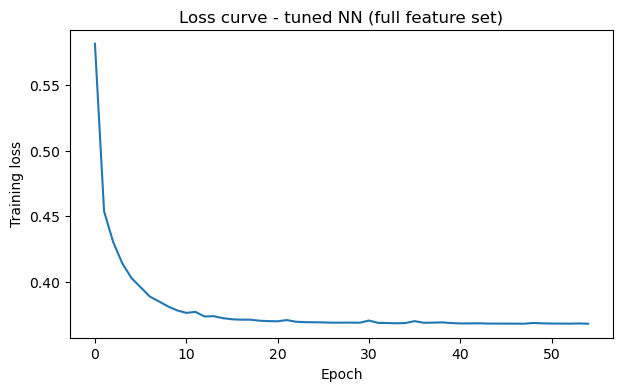

Number of iterations needed: 55


,param_hidden_layer_sizes,param_alpha,mean_train_score,mean_test_score,rank_test_score
9,"(25,)",1.00,0.711086,0.662895,1
10,"(50,)",1.00,0.709531,0.661940,2
11,"(100,)",1.00,0.710993,0.661404,3
12,"(25,)",10.00,0.660928,0.653742,4
13,"(50,)",10.00,0.659864,0.653481,5
14,"(100,)",10.00,0.656822,0.646757,6
6,"(25,)",0.10,0.790294,0.622709,7
3,"(25,)",0.01,0.798885,0.613116,8


In [87]:
# plot of loss curve
plt.figure(figsize=(7, 4))
plt.plot(task4_full_model.loss_curve_)
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Loss curve - tuned NN (full feature set)")
plt.show()

# print the number of iterations the model took to converge.
print("Number of iterations needed:", task4_full_model.n_iter_,)

# print the first 8 rows of the cross-validation results from the grid search.
cv_results = pd.DataFrame(task4_search.cv_results_)

cv_results[
    [
        "param_hidden_layer_sizes",
        "param_alpha",
        "mean_train_score",
        "mean_test_score",
        "rank_test_score",
    ]
].sort_values("rank_test_score").head(8)

### Task 4.3
##### Neural network modelling reduced dataset

In [88]:
from sklearn.feature_selection import SelectFromModel

# Task 4.3 - dimensionality reduction using the best decision tree from Task 2.
# SelectFromModel keeps features whose importance exceeds the mean importance.
task4_selector = SelectFromModel(optimal_dt_model_cv, prefit=True)

X_train_task4_reduced_raw = task4_selector.transform(X_train_task4_raw)
X_test_task4_reduced_raw = task4_selector.transform(X_test_task4_raw)

# Same NN-specific processing as 4.2: standardise, fitted on training data only
task4_reduced_scaler = StandardScaler()
X_train_task4_reduced = task4_reduced_scaler.fit_transform(X_train_task4_reduced_raw)
X_test_task4_reduced = task4_reduced_scaler.transform(X_test_task4_reduced_raw)

In [89]:
# same search as 4.2, but with a reduced parameter grid.
task4_reduced_param_grid = {
    'hidden_layer_sizes': [(25,), (50,), (100,)],
    'alpha': [0.001, 0.01, 0.1, 1.0, 10.0],
}

task4_reduced_search = GridSearchCV(
    MLPClassifier(max_iter=1000, random_state=random_state),
    param_grid=task4_reduced_param_grid,
    cv=10,
    scoring="roc_auc",
    n_jobs=-1,
    return_train_score=True,
    verbose=1,
)
task4_reduced_search.fit(X_train_task4_reduced, y_train_task4)

Fitting 10 folds for each of 15 candidates, totalling 150 fits


,estimator,MLPClassifier...ndom_state=10)
,param_grid,"{'alpha': [0.001, 0.01, ...], 'hidden_layer_sizes': [(25,), (50,), ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,10
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,hidden_layer_sizes,"(50,)"


In [90]:
print("Best parameters:  ", task4_reduced_search.best_params_)
task4_reduced_model = task4_reduced_search.best_estimator_

task4_reduced_train_accuracy = task4_reduced_model.score(X_train_task4_reduced, y_train_task4)
task4_reduced_test_accuracy = task4_reduced_model.score(X_test_task4_reduced, y_test_task4)
print(f"Training accuracy: {task4_reduced_train_accuracy:.4f}")
print(f"Test accuracy:     {task4_reduced_test_accuracy:.4f}")

task4_reduced_test_prob = task4_reduced_model.predict_proba(X_test_task4_reduced)[:, 1]
print(f"Test ROC AUC:      {roc_auc_score(y_test_task4, task4_reduced_test_prob):.4f}")

task4_reduced_test_pred = task4_reduced_model.predict(X_test_task4_reduced)
print(classification_report(y_test_task4, task4_reduced_test_pred))

Best parameters:   {'alpha': 0.1, 'hidden_layer_sizes': (50,)}
Training accuracy: 0.8707
Test accuracy:     0.8706
Test ROC AUC:      0.6679
              precision    recall  f1-score   support

           0       0.87      1.00      0.93     10820
           1       1.00      0.00      0.00      1610

    accuracy                           0.87     12430
   macro avg       0.94      0.50      0.47     12430
weighted avg       0.89      0.87      0.81     12430



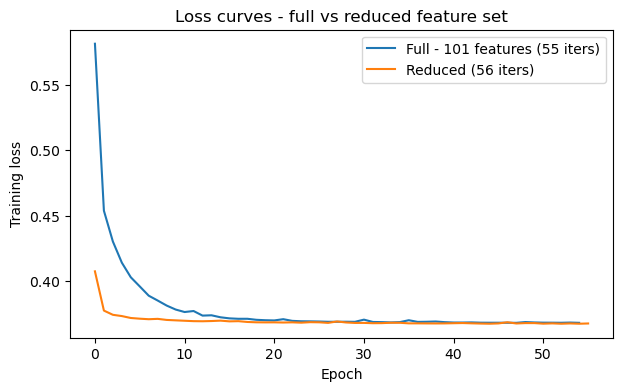

Iterations run: 56
  (full-feature model needed 55 iterations)


,param_hidden_layer_sizes,param_alpha,mean_train_score,mean_test_score,rank_test_score
7,"(50,)",0.100,0.664015,0.658071,1
8,"(100,)",0.100,0.664199,0.657494,2
4,"(50,)",0.010,0.667033,0.656981,3
5,"(100,)",0.010,0.670164,0.656878,4
1,"(50,)",0.001,0.667425,0.656835,5
6,"(25,)",0.100,0.661218,0.656097,6
2,"(100,)",0.001,0.671770,0.655817,7
3,"(25,)",0.010,0.661753,0.655349,8


In [91]:
# plot of loss curve for the reduced model, compared to the full model.
plt.figure(figsize=(7, 4))
plt.plot(task4_full_model.loss_curve_, label=f"Full - 101 features ({task4_full_model.n_iter_} iters)")
plt.plot(task4_reduced_model.loss_curve_, label=f"Reduced ({task4_reduced_model.n_iter_} iters)")
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Loss curves - full vs reduced feature set")
plt.legend()
plt.show()

# print the number of iterations the model took to converge.
print("Iterations run:", task4_reduced_model.n_iter_)
print("  (full-feature model needed", task4_full_model.n_iter_, "iterations)")

# print the first 8 rows of the cross-validation results from the grid search on the reduced feature set.
task4_reduced_cv_results = pd.DataFrame(task4_reduced_search.cv_results_)

task4_reduced_cv_results[
    [
        "param_hidden_layer_sizes",
        "param_alpha",
        "mean_train_score",
        "mean_test_score",
        "rank_test_score",
    ]
].sort_values("rank_test_score").head(8)

### Task 4.4

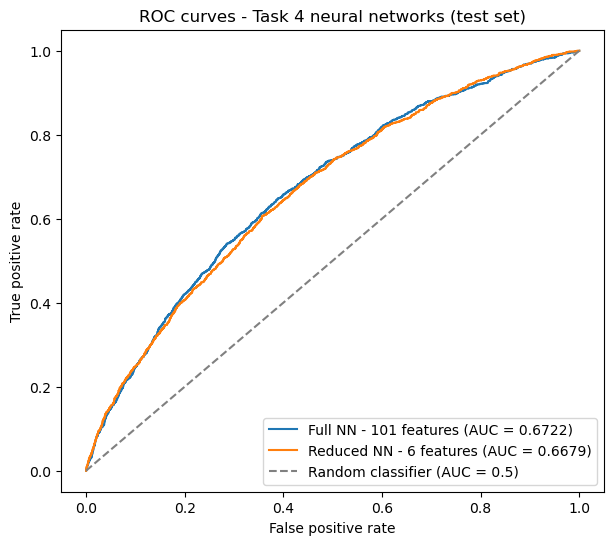

Full NN test ROC AUC:    0.6722
Reduced NN test ROC AUC: 0.6679


In [92]:
# Task 4.4 - ROC curves for both neural networks (test set)
task4_full_auc = roc_auc_score(y_test_task4, task4_full_test_prob)
task4_reduced_auc = roc_auc_score(y_test_task4, task4_reduced_test_prob)

task4_full_fpr, task4_full_tpr, _ = roc_curve(y_test_task4, task4_full_test_prob)
task4_reduced_fpr, task4_reduced_tpr, _ = roc_curve(y_test_task4, task4_reduced_test_prob)

plt.figure(figsize=(7, 6))
plt.plot(task4_full_fpr, task4_full_tpr,
         label=f"Full NN - 101 features (AUC = {task4_full_auc:.4f})")
plt.plot(task4_reduced_fpr, task4_reduced_tpr,
         label=f"Reduced NN - 6 features (AUC = {task4_reduced_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='grey', label="Random classifier (AUC = 0.5)")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curves - Task 4 neural networks (test set)")
plt.legend(loc="lower right")
plt.show()

print(f"Full NN test ROC AUC:    {task4_full_auc:.4f}")
print(f"Reduced NN test ROC AUC: {task4_reduced_auc:.4f}")

# Task 5 Analysis of Models

## ROC Curve Comparision of Models
The ROC curves of all six models perform better than the baseline. The Full Logistic Regression produced the **highest test ROC AUC (0.6738)**, followed by RFECV Logistic Regression (0.6737), Full Neural Network (0.6722), Reduced Neural Network (0.6679), GridSearchCV Decision Tree (0.6532), and lastly Default Decision Tree (0.5364)

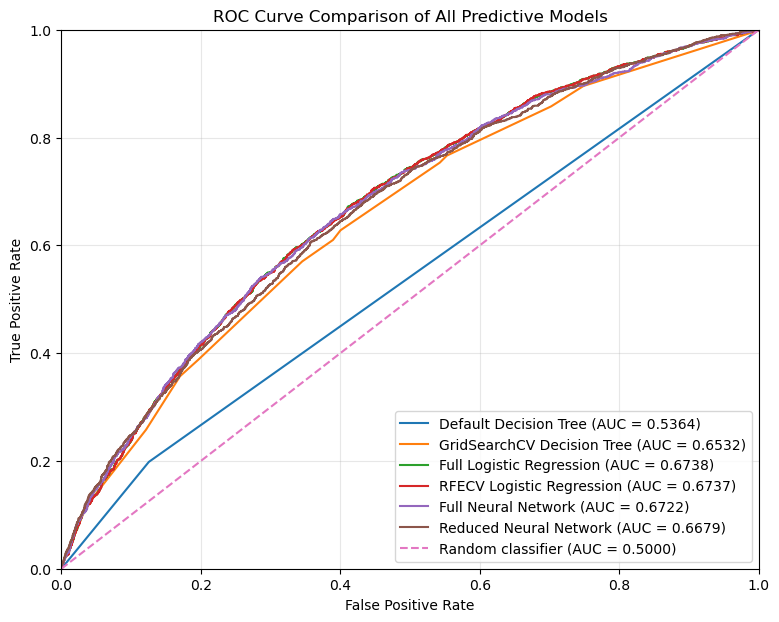

In [93]:
# Task 2 - Decision Trees
y_pred_proba_def_dt_model = def_dt_model.predict_proba(X_test)
y_pred_proba_optimal_dt_model_cv = optimal_dt_model_cv.predict_proba(X_test)

# Task 3 - Logistic Regression
# task3_full_test_prob and task3_reduced_test_prob
# were already calculated in Task 3.

# Task 4 - Neural Networks
# task4_full_test_prob and task4_reduced_test_prob
# were already calculated in Task 4.


# Calculate ROC AUC
roc_index_def_dt_model = roc_auc_score(
    y_test,
    y_pred_proba_def_dt_model[:, 1]
)

roc_index_optimal_dt_model_cv = roc_auc_score(
    y_test,
    y_pred_proba_optimal_dt_model_cv[:, 1]
)

task3_full_auc = roc_auc_score(
    y_test_task3,
    task3_full_test_prob
)

task3_reduced_auc = roc_auc_score(
    y_test_task3,
    task3_reduced_test_prob
)

task4_full_auc = roc_auc_score(
    y_test_task4,
    task4_full_test_prob
)

task4_reduced_auc = roc_auc_score(
    y_test_task4,
    task4_reduced_test_prob
)


# Calculate ROC curves
fpr_def_dt, tpr_def_dt, _ = roc_curve(
    y_test,
    y_pred_proba_def_dt_model[:, 1]
)

fpr_optimal_dt, tpr_optimal_dt, _ = roc_curve(
    y_test,
    y_pred_proba_optimal_dt_model_cv[:, 1]
)

fpr_full_lr, tpr_full_lr, _ = roc_curve(
    y_test_task3,
    task3_full_test_prob
)

fpr_reduced_lr, tpr_reduced_lr, _ = roc_curve(
    y_test_task3,
    task3_reduced_test_prob
)

fpr_full_nn, tpr_full_nn, _ = roc_curve(
    y_test_task4,
    task4_full_test_prob
)

fpr_reduced_nn, tpr_reduced_nn, _ = roc_curve(
    y_test_task4,
    task4_reduced_test_prob
)


# Plot ROC curves
plt.figure(figsize=(9, 7))

plt.plot(
    fpr_def_dt,
    tpr_def_dt,
    label=f"Default Decision Tree (AUC = {roc_index_def_dt_model:.4f})"
)

plt.plot(
    fpr_optimal_dt,
    tpr_optimal_dt,
    label=f"GridSearchCV Decision Tree (AUC = {roc_index_optimal_dt_model_cv:.4f})"
)

plt.plot(
    fpr_full_lr,
    tpr_full_lr,
    label=f"Full Logistic Regression (AUC = {task3_full_auc:.4f})"
)

plt.plot(
    fpr_reduced_lr,
    tpr_reduced_lr,
    label=f"RFECV Logistic Regression (AUC = {task3_reduced_auc:.4f})"
)

plt.plot(
    fpr_full_nn,
    tpr_full_nn,
    label=f"Full Neural Network (AUC = {task4_full_auc:.4f})"
)

plt.plot(
    fpr_reduced_nn,
    tpr_reduced_nn,
    label=f"Reduced Neural Network (AUC = {task4_reduced_auc:.4f})"
)

# Random classifier
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier (AUC = 0.5000)"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of All Predictive Models")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])

plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()

## Performance Comparision Table of Models
1. **Default Decision Tree** - Complex decision tree; high overfitting and lowest test ROC AUC; 
2. **GridSearchCV Decision Tree** - Simpler decision tree; little evidence of overfitting
3. **Full Logistic Regression** - Highest test ROC AUC; little evidence of overfitting
4. **RFECV Logistic Regression** - Almost the same as full logistic regression with lesser predictors
5. **Full Neural Network** - Slightly below full logistic regression; little evidence of overfitting
6. **Reduced Neural Network** - Similar to full neural neural network but slightly lower ROC AUC


In [94]:
# Training predictions
# Decision Trees
def_dt_train_pred = def_dt_model.predict(X_train)
optimal_dt_train_pred = optimal_dt_model_cv.predict(X_train)

# Logistic Regression
full_lr_train_pred = task3_full_search.best_estimator_.predict(X_train_task3)

reduced_lr_train_pred = task3_reduced_search.best_estimator_.predict(X_train_task3_reduced)

# Neural Networks
full_nn_train_pred = task4_full_model.predict(X_train_task4)

reduced_nn_train_pred = task4_reduced_model.predict(X_train_task4_reduced)

# Test predictions
# Decision Trees
def_dt_test_pred = def_dt_model.predict(X_test)
optimal_dt_test_pred = optimal_dt_model_cv.predict(X_test)

# Logistic Regression
full_lr_test_pred = task3_full_search.best_estimator_.predict(X_test_task3)

reduced_lr_test_pred = task3_reduced_search.best_estimator_.predict(X_test_task3_reduced)

# Neural Networks
full_nn_test_pred = task4_full_model.predict(X_test_task4)

reduced_nn_test_pred = task4_reduced_model.predict(X_test_task4_reduced)


# Create comparison table
task5_models_comparison = pd.DataFrame({
    
    "Model": [
        "Default Decision Tree",
        "GridSearchCV Decision Tree",
        "Full Logistic Regression",
        "RFECV Logistic Regression",
        "Full Neural Network",
        "Reduced Neural Network"
    ],
    
    "Training Accuracy": [
        accuracy_score(y_train, def_dt_train_pred),
        accuracy_score(y_train, optimal_dt_train_pred),
        accuracy_score(y_train_task3, full_lr_train_pred),
        accuracy_score(y_train_task3, reduced_lr_train_pred),
        accuracy_score(y_train_task4, full_nn_train_pred),
        accuracy_score(y_train_task4, reduced_nn_train_pred)
    ],
    
    "Test Accuracy": [
        accuracy_score(y_test, def_dt_test_pred),
        accuracy_score(y_test, optimal_dt_test_pred),
        accuracy_score(y_test_task3, full_lr_test_pred),
        accuracy_score(y_test_task3, reduced_lr_test_pred),
        accuracy_score(y_test_task4, full_nn_test_pred),
        accuracy_score(y_test_task4, reduced_nn_test_pred)
    ],
    
    "Test ROC AUC": [
        roc_index_def_dt_model,
        roc_index_optimal_dt_model_cv,
        task3_full_auc,
        task3_reduced_auc,
        task4_full_auc,
        task4_reduced_auc
    ]
})


# Format the values for easy use in the report
task5_models_display = task5_models_comparison.copy()

task5_models_display["Training Accuracy"] = (
    task5_models_display["Training Accuracy"] * 100
).map(lambda x: f"{x:.2f}%")

task5_models_display["Test Accuracy"] = (
    task5_models_display["Test Accuracy"] * 100
).map(lambda x: f"{x:.2f}%")

task5_models_display["Test ROC AUC"] = (
    task5_models_display["Test ROC AUC"]
).map(lambda x: f"{x:.4f}")


# Display table
display(task5_models_display)

,Model,Training Accuracy,Test Accuracy,Test ROC AUC
0,Default Decision Tree,100.00%,78.70%,0.5364
1,GridSearchCV Decision Tree,87.08%,87.06%,0.6532
2,Full Logistic Regression,87.04%,87.05%,0.6738
3,RFECV Logistic Regression,87.04%,87.05%,0.6737
4,Full Neural Network,87.05%,87.05%,0.6722
5,Reduced Neural Network,87.07%,87.06%,0.6679
